In [1]:
# ================================================================
# Cell 1 — Imports + Global Configuration
# light sommelier delta energy (Part 3)
# ================================================================
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# --- Random Seed (global for reproducibility) ---
rng = np.random.default_rng(42)

# --- Wavelength Grid ---
wl_min, wl_max, wl_step = 380, 700, 5
wavelengths = np.arange(wl_min, wl_max + wl_step, wl_step)
n_wl = len(wavelengths)

print("Cell 1 OK — Global imports + wavelength grid initialized.")
print("Wavelength grid size:", n_wl, "points")


Cell 1 OK — Global imports + wavelength grid initialized.
Wavelength grid size: 65 points


In [2]:
# ================================================================
# Cell 2 — Spectral Module (Clean Build)
# light sommelier delta energy (Part 3)
# ================================================================

import numpy as np

# 使用 Cell 1 中的 rng, wavelengths, n_wl

# ------------------------------------------------
# Gaussian 光谱生成器
# ------------------------------------------------
def make_gaussian_spectrum(center_nm, width_nm=20.0, peak=1.0):
    """
    生成高斯窄带光谱。
    """
    sigma = width_nm / 2.355
    return peak * np.exp(-0.5 * ((wavelengths - center_nm) / sigma) ** 2)


# ------------------------------------------------
# 生成随机 batch 的工具函数
# ------------------------------------------------
def make_batch_centers(n_centers=10, wl_lo=420, wl_hi=680):
    """
    生成用于 batch 刺激的中心波长列表（等距分布）。
    """
    return np.linspace(wl_lo, wl_hi, n_centers)


def make_stimuli_batch(centers,
                       n_repeats=6,
                       intensities=(0.5, 0.8),
                       noise_power=0.02):
    """
    基于中心波长生成多光谱 batch。
    """
    batch = []
    for c in centers:
        for peak in intensities:
            for _ in range(n_repeats):
                spec = make_gaussian_spectrum(c, width_nm=22, peak=peak)
                spec = np.clip(
                    spec + rng.normal(0, noise_power, size=spec.shape),
                    0, None
                )
                batch.append({'wl_center': float(c), 'spectrum': spec})
    rng.shuffle(batch)
    return batch


# ------------------------------------------------
# Two-Level Mixing 复杂光谱（升级版）
# ------------------------------------------------
def make_twolevel_mix():
    """
    构建具有两层混合结构的复杂光谱：
    (1) 同色频带的强/弱叠加  → Δ1 ↑
    (2) 异色频带的跨类叠加  → RG/BY 震荡 ↑
    """
    # 一级混合（同波段强弱）
    blue_strong = make_gaussian_spectrum(450, width_nm=25, peak=1.2)
    blue_weak   = make_gaussian_spectrum(450, width_nm=25, peak=0.4)

    # 二级混合（跨类别）
    green_mid   = make_gaussian_spectrum(530, width_nm=22, peak=0.8)
    red_strong  = make_gaussian_spectrum(610, width_nm=35, peak=1.0)

    # 组合权重可调，这里使用较稳定的组合
    spec = (
        1.0 * blue_strong +
        0.6 * blue_weak   +
        0.7 * green_mid   +
        1.0 * red_strong
    )

    return np.clip(spec, 0, None)


# ------------------------------------------------
# 测试 Two-Level Mixing 光谱
# ------------------------------------------------
complex_spec = make_twolevel_mix()

print("Cell 2 OK — Spectral module ready.")
print("Complex spectrum min/max:", complex_spec.min(), complex_spec.max())
print("Wavelength points:", len(wavelengths))

Cell 2 OK — Spectral module ready.
Complex spectrum min/max: 5.207375799353399e-10 1.44
Wavelength points: 65


In [3]:
# ================================================================
# Cell 3 — Receptor Bank + Pooling
# light sommelier delta energy (Part 3)
# ================================================================

import numpy as np

# 使用 Cell 1 中的:
# - rng
# - wavelengths, n_wl

# ------------------------------------------------
# Gaussian 敏感度生成器
# ------------------------------------------------
def gaussian_sensitivity(center_nm, width_nm=40.0):
    """
    生成单个受体的光谱敏感度。
    """
    sigma = width_nm / 2.355
    return np.exp(-0.5 * ((wavelengths - center_nm) / sigma) ** 2)


# ------------------------------------------------
# 构建 Receptor Bank（S/M/L 每簇 n_per_group 个）
# ------------------------------------------------
def make_receptor_bank(n_per_group=4, jitter=10.0, width_nm=40.0):
    """
    构建三簇受体：
      S-簇中心: 440 nm
      M-簇中心: 530 nm
      L-簇中心: 560 nm
    每簇 n_per_group 个受体，中心波长带 jitter。
    """
    S_center, M_center, L_center = 440, 530, 560
    base_centers = [S_center, M_center, L_center]

    centers = []
    for base in base_centers:
        centers.extend(base + rng.normal(0, jitter, size=n_per_group))

    centers = np.array(centers)

    sens = np.stack(
        [gaussian_sensitivity(c, width_nm=width_nm) for c in centers],
        axis=0
    )

    # Normalize each receptor channel
    sens = sens / (sens.max(axis=1, keepdims=True) + 1e-9)

    return sens, centers


# ------------------------------------------------
# Pooling：12 个受体 → 3 个簇（S/M/L）
# ------------------------------------------------
def build_cluster_map(n_per_group=4):
    """
    建立 receptor → cluster 的映射表。
    """
    return np.array([0]*n_per_group + [1]*n_per_group + [2]*n_per_group)


def pool_to_clusters(receptor_ts, cluster_map):
    """
    输入:
        receptor_ts: shape [T, n_receptors]
        cluster_map: 长度 n_receptors 的数组, 值域 {0,1,2}

    输出:
        pooled: shape [T, 3]
    """
    T, n_rec = receptor_ts.shape
    n_clusters = 3
    pooled = np.zeros((T, n_clusters))

    for k in range(n_clusters):
        idx = np.where(cluster_map == k)[0]
        pooled[:, k] = receptor_ts[:, idx].mean(axis=1)

    return pooled


# ------------------------------------------------
# 构建 receptor bank + cluster map
# ------------------------------------------------
receptor_sens, receptor_centers = make_receptor_bank(
    n_per_group=4,
    jitter=10.0,
    width_nm=40.0
)
cluster_map = build_cluster_map(n_per_group=4)

print("Cell 3 OK — receptor bank + pooling ready.")
print("Receptor matrix shape:", receptor_sens.shape)
print("Cluster map:", cluster_map)

Cell 3 OK — receptor bank + pooling ready.
Receptor matrix shape: (12, 65)
Cluster map: [0 0 0 0 1 1 1 1 2 2 2 2]


In [4]:
# ================================================================
# Cell 4 — Energy Module (Δ2-ready, Clean Build)
# light sommelier delta energy (Part 3)
# ================================================================

import numpy as np

# 使用全局 wavelengths
# h, c 使用正常物理量 + 缩放，避免数值爆炸
h = 6.626e-34        # Planck constant
c = 3e8              # speed of light
energy_scale = 1e27  # scaled so numeric range is usable


# ------------------------------------------------
# Photon Energy
# ------------------------------------------------
def photon_energy(wavelengths_nm):
    """
    光子能量 E = hc/λ，并进行缩放。
    输入单位 nm，会转换为 m。
    """
    wavelengths_m = wavelengths_nm * 1e-9
    E = (h * c) / wavelengths_m
    return E * energy_scale


# ------------------------------------------------
# 能态更新（无噪声版本）
# ------------------------------------------------
def update_energy(E_prev, processing_cost, recovery=0.03):
    """
    E(t+1) = E(t) - cost + recovery
    并限制到 [0, 1]
    """
    E_new = E_prev - processing_cost + recovery
    return float(np.clip(E_new, 0.0, 1.0))


# ------------------------------------------------
# 能态更新（带噪声版本，用于资源不定性实验）
# ------------------------------------------------
def update_energy_with_noise(E_prev,
                             processing_cost,
                             recovery=0.03,
                             noise_sigma=0.01):
    """
    在能态更新后加入轻微噪声，用于资源不定性实验。
    噪声 ∼ N(0, noise_sigma)
    """
    E_new = E_prev - processing_cost + recovery
    E_new += rng.normal(0, noise_sigma)
    return float(np.clip(E_new, 0.0, 1.0))


# ------------------------------------------------
# Δ2（能态导数）计算辅助函数
# ------------------------------------------------
def compute_delta2(Energy_seq):
    """
    输入：Energy_seq (list or array)
    输出：Δ2 序列，长度 T，第一项为 0（无前项可比）
    """
    Energy_seq = np.array(Energy_seq)
    d2 = np.zeros_like(Energy_seq)
    if len(Energy_seq) > 1:
        d2[1:] = Energy_seq[1:] - Energy_seq[:-1]
    return d2


print("Cell 4 OK — Energy module ready.")

Cell 4 OK — Energy module ready.


In [5]:
# ================================================================
# Cell 5 — Mitral Dynamics + Opponent Channels
# light sommelier delta energy (Part 3)
# ================================================================

import numpy as np

# ------------------------------------------------
# Mitral Cell Dynamics
# ------------------------------------------------
def run_mitral_dynamics(cluster_acts, alpha=0.3, inhib=0.4):
    """
    输入:
        cluster_acts: shape [T, 3], 分别对应 S/M/L 三簇输入

    输出:
        mitral_ts: shape [T, 3]
    """
    T = cluster_acts.shape[0]

    # 简单前馈权重（对角）
    W_in = np.eye(3)

    # 侧抑矩阵：全连接抑制（无对角）
    L = inhib * (np.ones((3, 3)) - np.eye(3))

    # 初值
    m = np.zeros(3)
    mitral_ts = []

    for t in range(T):
        drive = W_in @ cluster_acts[t]    # 前馈
        lateral = L @ m                   # 侧抑
        m = (1 - alpha) * m + alpha * np.maximum(0, drive - lateral)
        mitral_ts.append(m.copy())

    return np.stack(mitral_ts, axis=0)


# ------------------------------------------------
# Opponent Channels
# ------------------------------------------------
def opponent_channels(mitral_ts):
    """
    输入:
        mitral_ts: shape [T, 3]
    输出:
        RG, BY, LUM: 各为长度 T 的数组
    """
    S = mitral_ts[:, 0]
    M = mitral_ts[:, 1]
    L = mitral_ts[:, 2]

    RG = L - M
    BY = 0.5 * (L + M) - S
    LUM = L + M + S

    return {
        'RG': RG,
        'BY': BY,
        'LUM': LUM
    }


print("Cell 5 OK — Mitral dynamics + opponent channels ready.")

Cell 5 OK — Mitral dynamics + opponent channels ready.


In [6]:
# ================================================================
# Cell 6 — Soft-Gate Decision Layer (Δ2 sign-flip integrated)
# light sommelier delta energy (Part 3)
# ================================================================

import numpy as np

# ------------------------------------------------
# Sigmoid
# ------------------------------------------------
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


# ------------------------------------------------
# Soft-Gate 核心：Δ1 + Δ2
# ------------------------------------------------
def soft_gate_core(delta1, delta2, gamma1=5.0, gamma2=5.0):
    """
    F = exp(-γ1 * |Δ1|) * sigmoid(-γ2 * Δ2)
    """
    return np.exp(-gamma1 * abs(delta1)) * sigmoid(-gamma2 * delta2)


# ------------------------------------------------
# Instability Gate: Δ₂ 符号反转敏感
# ------------------------------------------------
def soft_gate_instability(F, delta2_prev, delta2_now, penalty=0.5):
    """
    如果 Δ2 符号反转（能态趋势不稳定） → 加强 early stop 的概率。

    penalty < 1 → 更容易提前终止
    """
    if np.sign(delta2_prev) != np.sign(delta2_now):
        return F * penalty
    return F


# ------------------------------------------------
# 动态阈值（随能态提高）
# ------------------------------------------------
def compute_threshold(E_t, base_thresh=0.15):
    return base_thresh + 0.20 * E_t


# ------------------------------------------------
# 决策竞争动力学（BW vs COLOR）
# ------------------------------------------------
def decision_competition_energy_v2(
        RG, BY, LUM,
        Energy_seq,
        gamma1=5.0, gamma2=1.5,
        alpha_dec=0.25,
        inhib_dec=0.6,
        theta_F=0.15,
        instability_penalty=0.8):
    """
    输出：
        BW_ts, COLOR_ts, RG_fb, BY_fb, F_values, stop_t
    """

    T = len(RG)

    # 初始化
    BW = 0.1
    COLOR = 0.1

    BW_ts = []
    COLOR_ts = []
    RG_fb = RG.copy()
    BY_fb = BY.copy()
    F_values = []
    stop_t = None

    # Δ₂ tracking
    delta2_prev = 0.0

    for t in range(T):

        E_t = Energy_seq[t]
        thresh = compute_threshold(E_t)

        # ------------ 1. 决策驱动 ------------
        drive_bw = (1.0 * LUM[t] - 0.6 * RG[t] - 0.6 * BY[t])
        drive_color = (1.2 * RG[t] + 1.2 * BY[t])

        comp_strength = inhib_dec * (0.5 + 0.5 * E_t)

        # ------------ 2. 动力系统更新 ------------
        BW = (1 - alpha_dec) * BW + alpha_dec * max(0, drive_bw - comp_strength * COLOR)
        COLOR = (1 - alpha_dec) * COLOR + alpha_dec * max(0, drive_color - comp_strength * BW)

        BW_ts.append(BW)
        COLOR_ts.append(COLOR)

        # ------------ 3. Soft‑Gate Δ1, Δ2 ------------
        if t > 0:
            delta1 = abs((COLOR_ts[t] - BW_ts[t]) -
                         (COLOR_ts[t-1] - BW_ts[t-1]))
            delta2_now = Energy_seq[t] - Energy_seq[t-1]

            # 基础 soft‑gate
            F_t = soft_gate_core(delta1, delta2_now, gamma1, gamma2)

            # Δ₂ 符号反转敏感
            F_t = soft_gate_instability(F_t, delta2_prev, delta2_now,
                                        penalty=instability_penalty)

            F_values.append(F_t)

            # ---- 终止判定 ----
            if F_t < theta_F:
                stop_t = t
                print(f"[Soft-Gate] Terminated at t = {t}  (F = {F_t:.4f})")

                # 截断
                BW_ts = BW_ts[:t+1]
                COLOR_ts = COLOR_ts[:t+1]
                RG_fb = RG_fb[:t+1]
                BY_fb = BY_fb[:t+1]

                return (
                    np.array(BW_ts),
                    np.array(COLOR_ts),
                    np.array(RG_fb),
                    np.array(BY_fb),
                    F_values,
                    stop_t
                )

            delta2_prev = delta2_now

        else:
            # 第 0 步无 Δ1/Δ2
            F_values.append(None)

        # ------------ 4. 能态反向塑形（feedback）------------
        fb_gain = 0.10 + 0.30 * E_t
        delta = COLOR - BW

        RG_fb[t] = RG[t] + fb_gain * delta
        BY_fb[t] = BY[t] + fb_gain * delta

    # 若未提前终止
    return (
        np.array(BW_ts),
        np.array(COLOR_ts),
        np.array(RG_fb),
        np.array(BY_fb),
        F_values,
        stop_t
    )


print("Cell 6 OK — Soft-Gate v2 (Δ2 sign-flip) ready.")

Cell 6 OK — Soft-Gate v2 (Δ2 sign-flip) ready.


In [7]:
# ================================================================
# Cell 7 — Energy Pipeline (Δ2-ready, Clean Build)
# light sommelier delta energy (Part 3)
# ================================================================

import numpy as np

# 使用先前 Cells 中导入的:
# - receptor_sens
# - cluster_map
# - update_energy / update_energy_with_noise
# - compute_delta2
# - run_mitral_dynamics
# - opponent_channels
# - decision_competition_energy_v2
# - photon_energy


# ------------------------------------------------
# 受体层：响应函数（含能态调制 + photon energy）
# ------------------------------------------------
def receptor_response_with_energy(
        spectrum,
        receptor_sens,
        wavelengths,
        Energy_t):
    """
    输入：
        spectrum: 光谱（长度 n_wl）
        receptor_sens: shape [n_receptors, n_wl]
        Energy_t: 当前能态

    输出：
        receptor activation shape [n_receptors]
    """

    # 光子能量组件（增加高能波段权重）
    photon_E = photon_energy(wavelengths)
    weighted_spec = spectrum * (0.3 + 0.7 * (photon_E / photon_E.max()))

    # 受体基础响应
    base = receptor_sens @ weighted_spec

    # 能态调制敏感度锐度
    sharpness = 0.5 + 0.5 * Energy_t  # ∈ [0.5, 1.0]
    base = np.power(base, sharpness)

    return np.clip(base, 0, None)


# ------------------------------------------------
# Activation Cost（用于能态更新）
# ------------------------------------------------
def activation_cost(
        receptor_act,
        mitral_prev,
        BW_prev,
        COLOR_prev,
        w_rec=0.04,
        w_mitral=0.05,
        w_dec=0.08):
    """
    基于受体 / mitral / BW-COLOR 的激活强度计算能耗。
    """
    rec_cost = np.mean(np.abs(receptor_act))
    mit_cost = np.mean(np.abs(mitral_prev))
    dec_cost = (abs(BW_prev) + abs(COLOR_prev)) / 2.0

    total_cost = (w_rec * rec_cost +
                  w_mitral * mit_cost +
                  w_dec * dec_cost)

    return float(total_cost)


# ------------------------------------------------
# Energy Pipeline (主函数)
# ------------------------------------------------
def run_energy_pipeline(
        spectrum,
        receptor_sens,
        wavelengths,
        T=40,
        gate=None,
        use_energy_noise=False,
        noise_sigma=0.01):
    """
    整个管线：
      receptor → pooling → mitral → opponent → decision(Soft-Gate)
    """

    if gate is None:
        gate = np.ones(T)

    # ----- 初始化 -----
    receptor_ts = []
    Energy_seq = []
    E_t = 1.0

    BW_prev = 0.1
    COLOR_prev = 0.1
    mitral_prev = np.zeros(3)

    # ============================
    # (1) 受体层 + 能态更新
    # ============================
    for t in range(T):
        # --- receptor activation ---
        rec = receptor_response_with_energy(
            spectrum,
            receptor_sens,
            wavelengths,
            E_t
        )
        rec = rec * gate[t]
        receptor_ts.append(rec)

        # --- 能耗计算 ---
        cost = activation_cost(
            rec, mitral_prev, BW_prev, COLOR_prev
        )

        # --- 能态更新（可选噪声） ---
        if use_energy_noise:
            E_t = update_energy_with_noise(
                E_t, cost,
                recovery=0.01,
                noise_sigma=noise_sigma
            )
        else:
            E_t = update_energy(E_t, cost, recovery=0.001)

        Energy_seq.append(E_t)

    receptor_ts = np.stack(receptor_ts, axis=0)

    # ============================
    # (2) pooling to S/M/L clusters
    # ============================
    cluster_acts = pool_to_clusters(receptor_ts, cluster_map)

    # ============================
    # (3) mitral dynamics
    # ============================
    mitral_ts = run_mitral_dynamics(cluster_acts)
    mitral_prev = mitral_ts[-1]

    # ============================
    # (4) Opponent channels
    # ============================
    opp = opponent_channels(mitral_ts)
    RG = opp['RG']
    BY = opp['BY']
    LUM = opp['LUM']

    # ============================
    # (5) Soft-Gate 决策层 v2
    # ============================
    BW, COLOR, RG_fb, BY_fb, F_values, stop_t = \
        decision_competition_energy_v2(
            RG, BY, LUM,
            Energy_seq
        )

    # ===== 更新 prev（用于下一 pipeline loop 时） =====
    if len(BW) > 0:
        BW_prev = BW[-1]
        COLOR_prev = COLOR[-1]

    # ============================
    # 输出
    # ============================
    return (
        RG, BY,
        RG_fb, BY_fb,
        BW, COLOR,
        np.array(Energy_seq),
        F_values,
        stop_t
    )


print("Cell 7 OK — Energy Pipeline (Δ2-ready) is ready.")

Cell 7 OK — Energy Pipeline (Δ2-ready) is ready.


In [8]:
# ================================================================
# Cell 8 — Plotting Module (Clean Build)
# light sommelier delta energy (Part 3)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

def plot_energy_trajectory(
        RG, BY,
        RG_fb, BY_fb,
        BW, COLOR,
        Energy_ts,
        title="Energy Model Trajectory"):
    """
    三联图显示：
      (1) RG/BY 中间态轨迹（含反馈前后）
      (2) BW/COLOR 决策轨迹（含 early stop）
      (3) 能态 Energy(t)
    """

    # --- 自适应时间轴 ---
    T_dec = len(BW)
    T_energy = len(Energy_ts)
    t_dec = np.arange(T_dec)
    t_energy = np.arange(T_energy)

    # ---------------------------------------------------------------
    # 画图
    # ---------------------------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # (1) RG-BY 中间态轨迹
    ax = axes[0]
    ax.plot(RG, BY, 'o--', alpha=0.4, label='原始 RG/BY')
    ax.plot(RG_fb, BY_fb, 'o-', alpha=0.9, label='能态反向塑形')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)
    ax.set_xlabel("RG (L - M)")
    ax.set_ylabel("BY (0.5*(L+M) - S)")
    ax.set_title("中间态轨迹")
    ax.legend()

    # (2) BW / COLOR 决策轨迹
    ax = axes[1]
    ax.plot(t_dec, BW, label='BW')
    ax.plot(t_dec, COLOR, label='COLOR')
    ax.set_xlabel("time")
    ax.set_ylabel("activation")
    ax.set_title("BW / COLOR 决策层")
    ax.set_ylim(0, 1.0)
    ax.legend()

    # (3) 能态轨迹
    ax = axes[2]
    ax.plot(t_energy, Energy_ts, color='green')
    ax.set_xlabel("time")
    ax.set_ylabel("Energy(t)")
    ax.set_title("能态轨迹")
    ax.set_ylim(0, 1.0)

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

print("Cell 8 OK — Plotting module ready.")

Cell 8 OK — Plotting module ready.


[Soft-Gate] Terminated at t = 3  (F = 0.1489)


C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2556521032.py:63: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2556521032.py:63: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2556521032.py:63: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2556521032.py:63: UserWarning: Glyph 36712 (\N{CJK UNIFIED IDEOGRAPH-8F68}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2556521032.py:63: UserWarning: Glyph 36857 (\N{CJK UNIFIED IDEOGRAPH-8FF9}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2556521032.py:63: UserWarning: Glyph 21407 (\

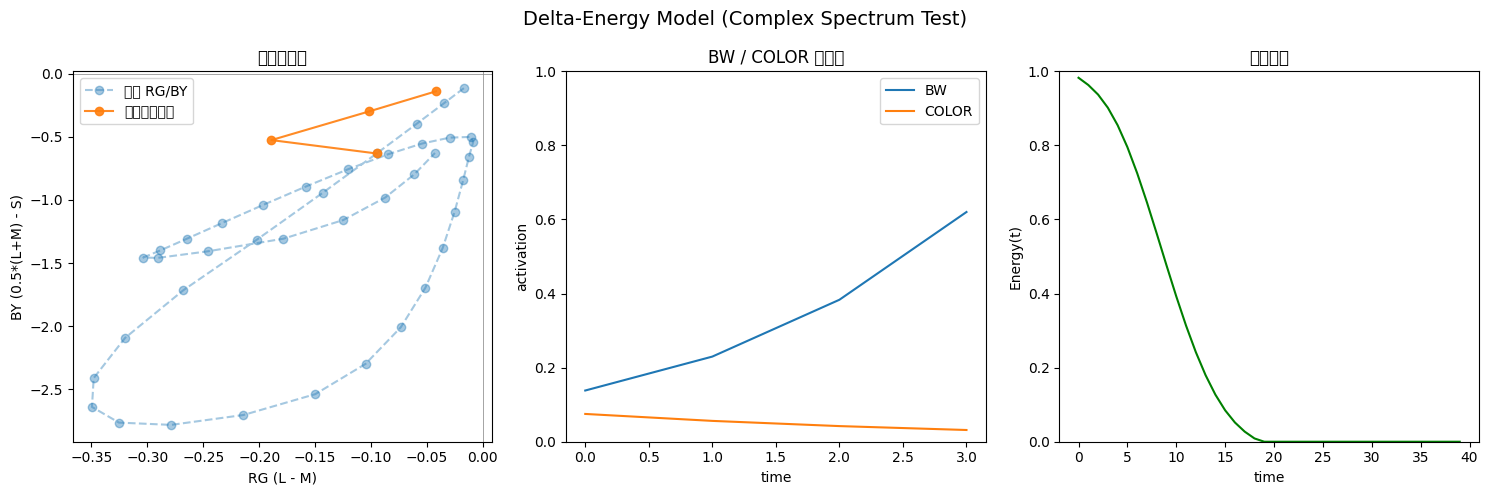


Soft-Gate stop_t: 3
Cell 9 OK — End-to-end test completed.


In [9]:
# ================================================================
# Cell 9 — End-to-End Test (Complex Spectrum)
# light sommelier delta energy (Part 3)
# ================================================================

# 使用 complex_spec (Cell 2)
# 使用 run_energy_pipeline (Cell 7)
# 使用 plot_energy_trajectory (Cell 8)

# ---- 相位门控（默认 sin^2 形态） ----
def make_phase_gate(T=40, freq=1.0, phase=0.0):
    """
    gate(t) = sin^2( 2π * freq * (t/T) + phase )
    并归一化到 [0.1, 1.0]
    """
    t = np.arange(T)
    raw = np.sin(2 * np.pi * (freq * t / T) + phase) ** 2

    # 归一化到 [0, 1]
    raw_min, raw_max = raw.min(), raw.max()
    if raw_max - raw_min < 1e-12:
        norm = np.ones(T)
    else:
        norm = (raw - raw_min) / (raw_max - raw_min)

    gate = 0.1 + 0.9 * norm
    return gate


T = 40
phase_gate = make_phase_gate(T=T)

# ---- 运行 delta-energy pipeline ----
RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_values, stop_t = \
    run_energy_pipeline(
        complex_spec,
        receptor_sens,
        wavelengths,
        T=T,
        gate=phase_gate,
        use_energy_noise=False  # 首次实验使用稳定能态
    )

# ---- 画三联图 ----
plot_energy_trajectory(
    RG, BY,
    RG_fb, BY_fb,
    BW, COLOR,
    Energy_ts,
    title="Delta-Energy Model (Complex Spectrum Test)"
)

print("\nSoft-Gate stop_t:", stop_t)
print("Cell 9 OK — End-to-end test completed.")

[Soft-Gate] Terminated at t = 5  (F = 0.1100)
[Soft-Gate] Terminated at t = 7  (F = 0.1351)
[Soft-Gate] Terminated at t = 5  (F = 0.1275)
[Soft-Gate] Terminated at t = 6  (F = 0.1335)
[Soft-Gate] Terminated at t = 6  (F = 0.1327)
[Soft-Gate] Terminated at t = 3  (F = 0.1287)
[Soft-Gate] Terminated at t = 6  (F = 0.1439)
[Soft-Gate] Terminated at t = 6  (F = 0.1418)
[Soft-Gate] Terminated at t = 5  (F = 0.1227)
[Soft-Gate] Terminated at t = 5  (F = 0.1168)
[Soft-Gate] Terminated at t = 5  (F = 0.1342)
[Soft-Gate] Terminated at t = 7  (F = 0.1310)
[Soft-Gate] Terminated at t = 7  (F = 0.1335)
[Soft-Gate] Terminated at t = 7  (F = 0.1383)
[Soft-Gate] Terminated at t = 6  (F = 0.1401)
[Soft-Gate] Terminated at t = 5  (F = 0.1432)
[Soft-Gate] Terminated at t = 6  (F = 0.1455)
Batch test finished.
stop_t values: [40  5 40 40 40  7  5  6  6  3  6 40  6  5  5  5  7 40 40  7 40 40  7  6
  5 40 40  6 40 40]
Δ2(1) values: [-0.01513863 -0.01616466 -0.00700179 -0.01321374 -0.01876854 -0.0156016
 -0

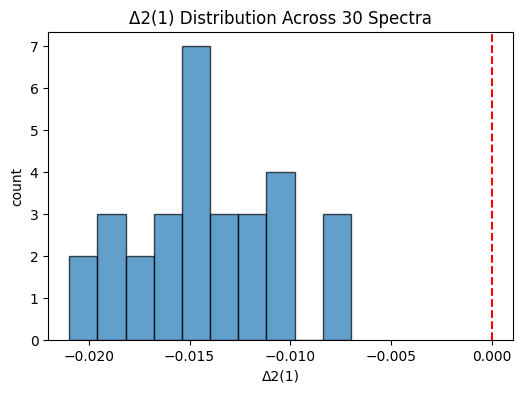

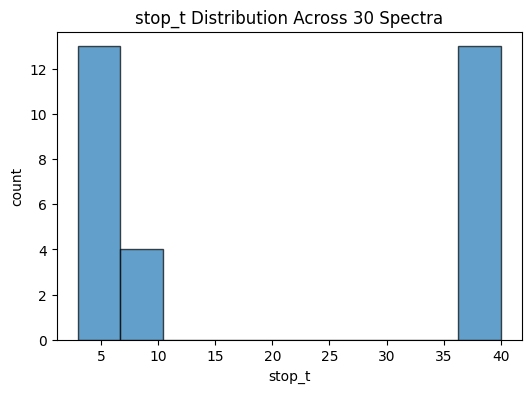

Cell 10 OK — Batch spectrum test completed.


In [10]:
# ================================================================
# Cell 10 — Batch Spectrum Test (Multi-sample Evaluation)
# light sommelier delta energy (Part 3)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------
# 生成不同类型的光谱样本
# ------------------------------------------------
def generate_random_spectrum():
    """
    生成一个随机光谱，用于测试多样输入：
    包括：
      - 随机 Gaussian
      - 随机多峰
      - 随机宽带
    """
    choice = rng.choice(["gauss", "multi", "wide"])

    if choice == "gauss":
        c = rng.uniform(420, 680)
        w = rng.uniform(10, 40)
        p = rng.uniform(0.5, 1.2)
        return make_gaussian_spectrum(c, width_nm=w, peak=p)

    elif choice == "multi":
        # 多峰组合
        c1 = rng.uniform(430, 500)
        c2 = rng.uniform(520, 600)
        s1 = make_gaussian_spectrum(c1, width_nm=rng.uniform(15, 35), peak=rng.uniform(0.4, 1.2))
        s2 = make_gaussian_spectrum(c2, width_nm=rng.uniform(15, 35), peak=rng.uniform(0.4, 1.2))
        return np.clip(s1 + s2, 0, None)

    else:  # wide
        c = rng.uniform(480, 580)
        w = rng.uniform(50, 120)
        p = rng.uniform(0.4, 1.0)
        return make_gaussian_spectrum(c, width_nm=w, peak=p)


# ------------------------------------------------
# 批量运行
# ------------------------------------------------
def batch_test_energy_pipeline(
        N=30,
        T=40,
        use_energy_noise=False,
        recovery_test=None):
    """
    对 N 个光谱进行运行，收集 stop_t 和 Δ2(1) 分布。
    """

    stop_ts = []
    delta2_first = []

    # phase gate
    phase_gate = make_phase_gate(T=T)

    for i in range(N):
        spec = generate_random_spectrum()

        RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_vals, stop_t = \
            run_energy_pipeline(
                spec,
                receptor_sens,
                wavelengths,
                T=T,
                gate=phase_gate,
                use_energy_noise=use_energy_noise,
                noise_sigma=0.01
            )

        stop_ts.append(stop_t if stop_t is not None else T)

        # 计算 Δ2
        d2 = compute_delta2(Energy_ts)
        delta2_first.append(d2[1])

    return np.array(stop_ts), np.array(delta2_first)


# ------------------------------------------------
# 默认运行 30 个光谱
# ------------------------------------------------
stop_ts, delta2_first = batch_test_energy_pipeline(N=30)

print("Batch test finished.")
print("stop_t values:", stop_ts)
print("Δ2(1) values:", delta2_first)

# ------------------------------------------------
# 直方图绘制 Δ2(1) 分布
# ------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(delta2_first, bins=10, alpha=0.7, edgecolor='black')
plt.axvline(0, color='red', linestyle='--')
plt.title("Δ2(1) Distribution Across 30 Spectra")
plt.xlabel("Δ2(1)")
plt.ylabel("count")
plt.show()

# ------------------------------------------------
# stop_t 分布图
# ------------------------------------------------
plt.figure(figsize=(6,4))
plt.hist(stop_ts, bins=10, alpha=0.7, edgecolor='black')
plt.title("stop_t Distribution Across 30 Spectra")
plt.xlabel("stop_t")
plt.ylabel("count")
plt.show()

print("Cell 10 OK — Batch spectrum test completed.")

[Soft-Gate] Terminated at t = 3  (F = 0.1489)


C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 65288 (\

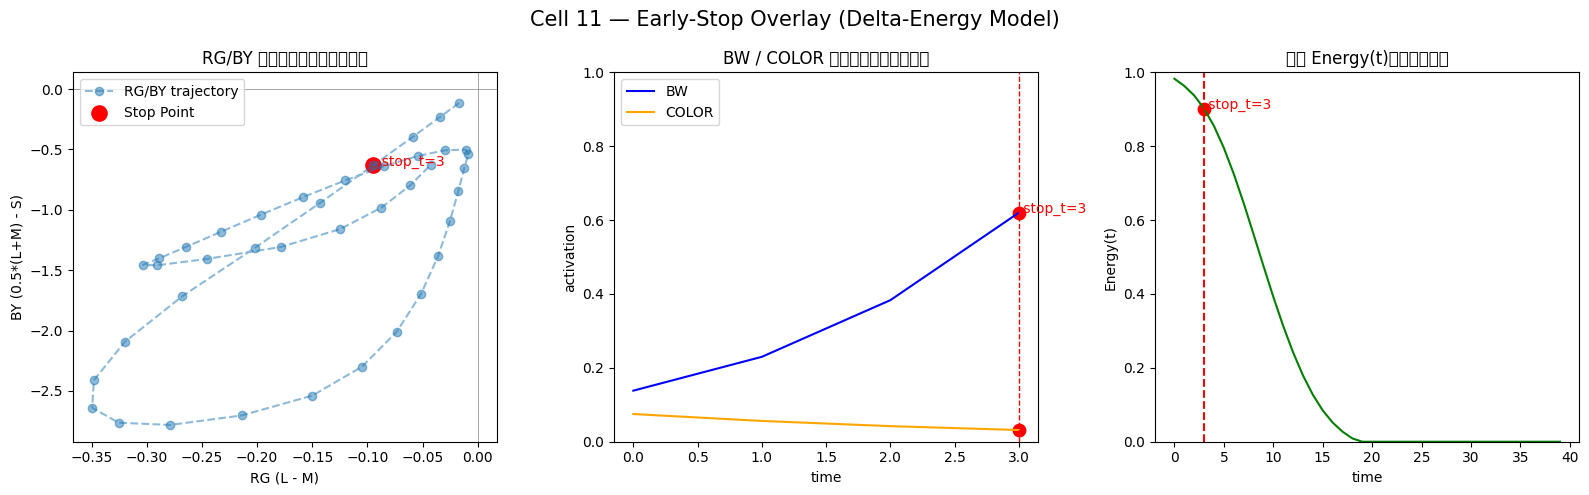

Cell 11 OK — Early-stop overlay plot generated.
stop_t = 3


In [11]:
# ================================================================
# Cell 11 — Early-Stop Overlay: RG/BY + BW/COLOR + Energy
# ================================================================
import numpy as np
import matplotlib.pyplot as plt

def plot_with_earlystop_overlay(
    RG, BY,
    BW, COLOR,
    Energy_ts,
    stop_t,
    title="Early-Stop Overlay Trajectory"
):
    """
    在三联图中标记 early-stop 点：
    (1) RG/BY 平面
    (2) BW/COLOR 决策曲线
    (3) Energy(t)
    """
    # 时间轴
    t_dec = np.arange(len(BW))
    t_energy = np.arange(len(Energy_ts))

    # ---------------------------------------------
    # 画图
    # ---------------------------------------------
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))

    # ===== (1) RG/BY 平面 + 停止点 =====
    ax = axes[0]
    ax.plot(RG, BY, 'o--', alpha=0.5, label='RG/BY trajectory')
    ax.axhline(0, color='gray', lw=0.5)
    ax.axvline(0, color='gray', lw=0.5)

    if stop_t is not None:
        ax.scatter(RG[stop_t], BY[stop_t], s=120, c='red', label='Stop Point')
        ax.text(RG[stop_t], BY[stop_t], f"  stop_t={stop_t}", color='red')

    ax.set_xlabel("RG (L - M)")
    ax.set_ylabel("BY (0.5*(L+M) - S)")
    ax.set_title("RG/BY 中间态平面（带停止点）")
    ax.legend()

    # ===== (2) BW / COLOR 决策轨迹 =====
    ax = axes[1]
    ax.plot(t_dec, BW, label='BW', color='blue')
    ax.plot(t_dec, COLOR, label='COLOR', color='orange')

    if stop_t is not None:
        # 垂直线
        ax.axvline(stop_t, color='red', linestyle='--', lw=1)
        ax.scatter(stop_t, BW[stop_t], c='red', s=80)
        ax.scatter(stop_t, COLOR[stop_t], c='red', s=80)
        ax.text(stop_t, max(BW[stop_t], COLOR[stop_t]),
                f" stop_t={stop_t}", color='red')

    ax.set_xlabel("time")
    ax.set_ylabel("activation")
    ax.set_title("BW / COLOR 分岔轨迹（带停止点）")
    ax.set_ylim(0, 1.0)
    ax.legend()

    # ===== (3) 能态 Energy(t) =====
    ax = axes[2]
    ax.plot(t_energy, Energy_ts, color='green')

    if stop_t is not None:
        ax.axvline(stop_t, color='red', linestyle='--')
        ax.scatter(stop_t, Energy_ts[stop_t], c='red', s=80)
        ax.text(stop_t, Energy_ts[stop_t],
                f" stop_t={stop_t}", color='red')

    ax.set_xlabel("time")
    ax.set_ylabel("Energy(t)")
    ax.set_title("能态 Energy(t)（带停止点）")
    ax.set_ylim(0, 1.0)

    fig.suptitle(title, fontsize=15)
    plt.tight_layout()
    plt.show()


# ================================================================
# 运行一次 Pipeline + 绘制 Early-Stop Overlay
# ================================================================
T = 40
phase_gate = make_phase_gate(T=T)

# 调用你的完整 Pipeline（使用当前全局 recovery=0.03）
RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_values, stop_t = \
    run_energy_pipeline(
        complex_spec,              # 你在 Cell 2 生成的多层混合光谱
        receptor_sens,
        wavelengths,
        T=T,
        gate=phase_gate,
        use_energy_noise=False
    )

# 绘图
plot_with_earlystop_overlay(
    RG, BY,
    BW, COLOR,
    Energy_ts,
    stop_t,
    title="Cell 11 — Early-Stop Overlay (Delta-Energy Model)"
)

print("Cell 11 OK — Early-stop overlay plot generated.")
print("stop_t =", stop_t)

[Soft-Gate] Terminated at t = 5  (F = 0.1475)


C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 20013 (\N{CJK UNIFIED IDEOGRAPH-4E2D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 24577 (\N{CJK UNIFIED IDEOGRAPH-6001}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 24179 (\N{CJK UNIFIED IDEOGRAPH-5E73}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 38754 (\N{CJK UNIFIED IDEOGRAPH-9762}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\cheny\AppData\Local\Temp\ipykernel_49032\2005575473.py:79: UserWarning: Glyph 65288 (\

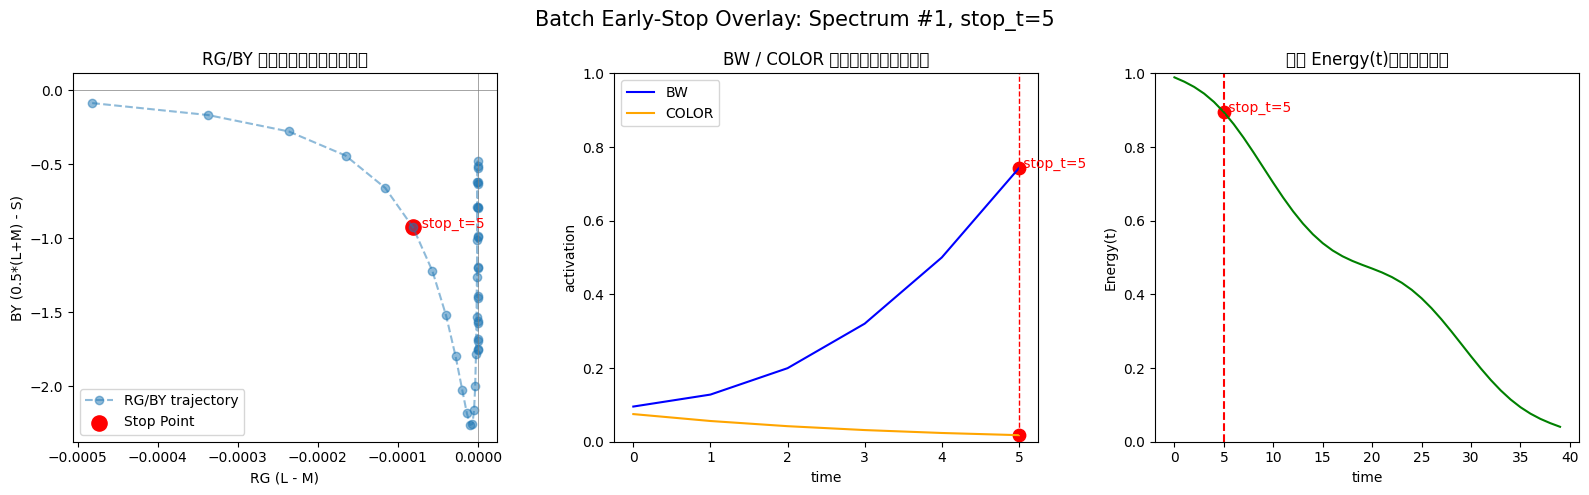

[Done] Spectrum 1/12, stop_t = 5

[Soft-Gate] Terminated at t = 9  (F = 0.1390)


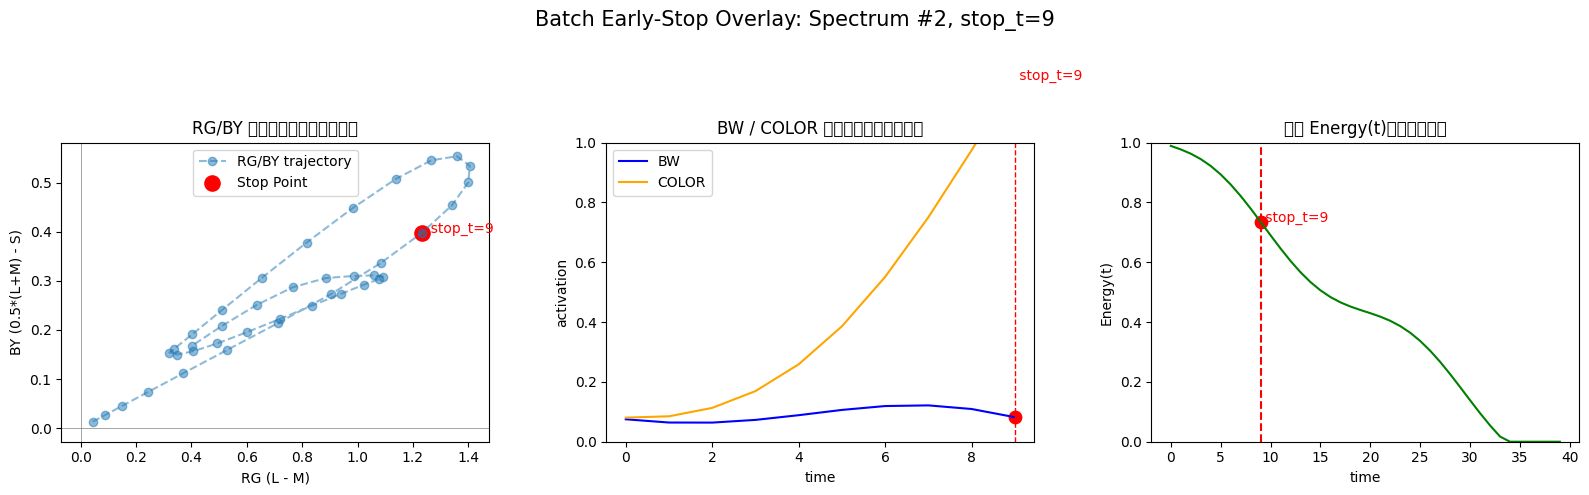

[Done] Spectrum 2/12, stop_t = 9

[Soft-Gate] Terminated at t = 5  (F = 0.1183)


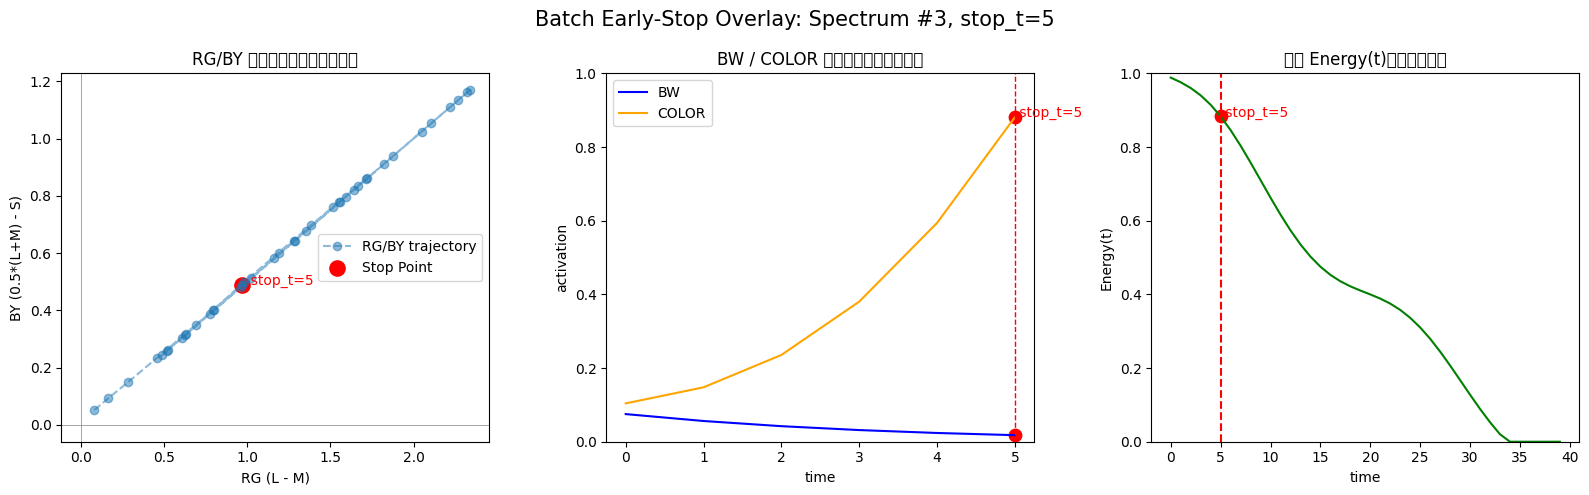

[Done] Spectrum 3/12, stop_t = 5



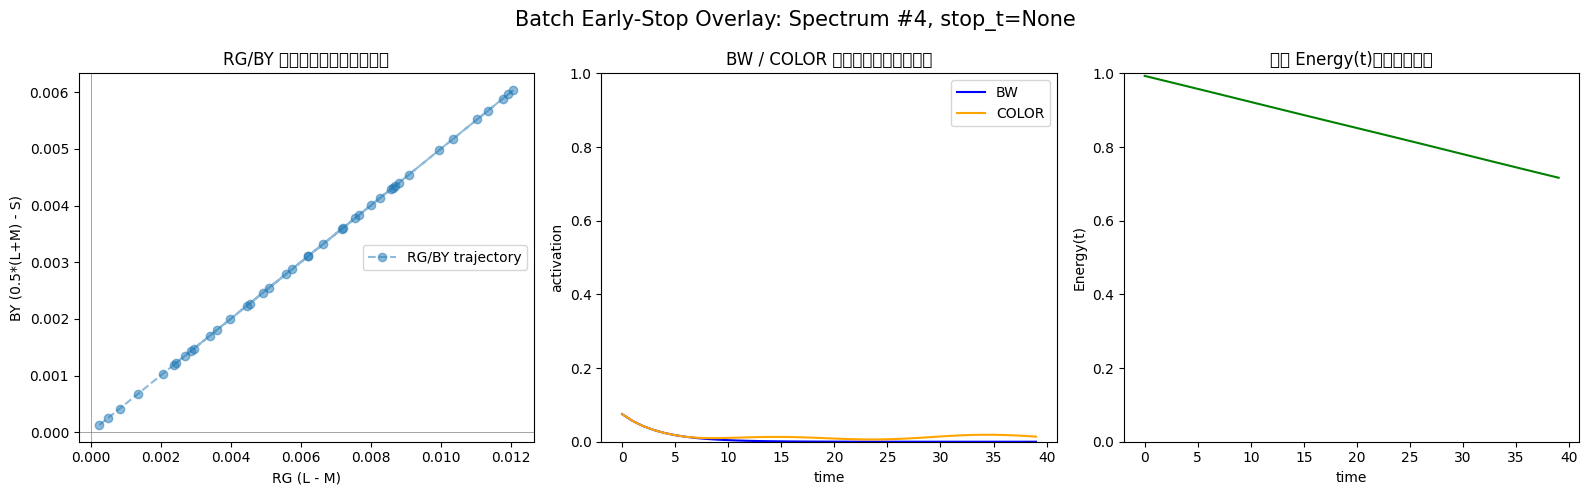

[Done] Spectrum 4/12, stop_t = None



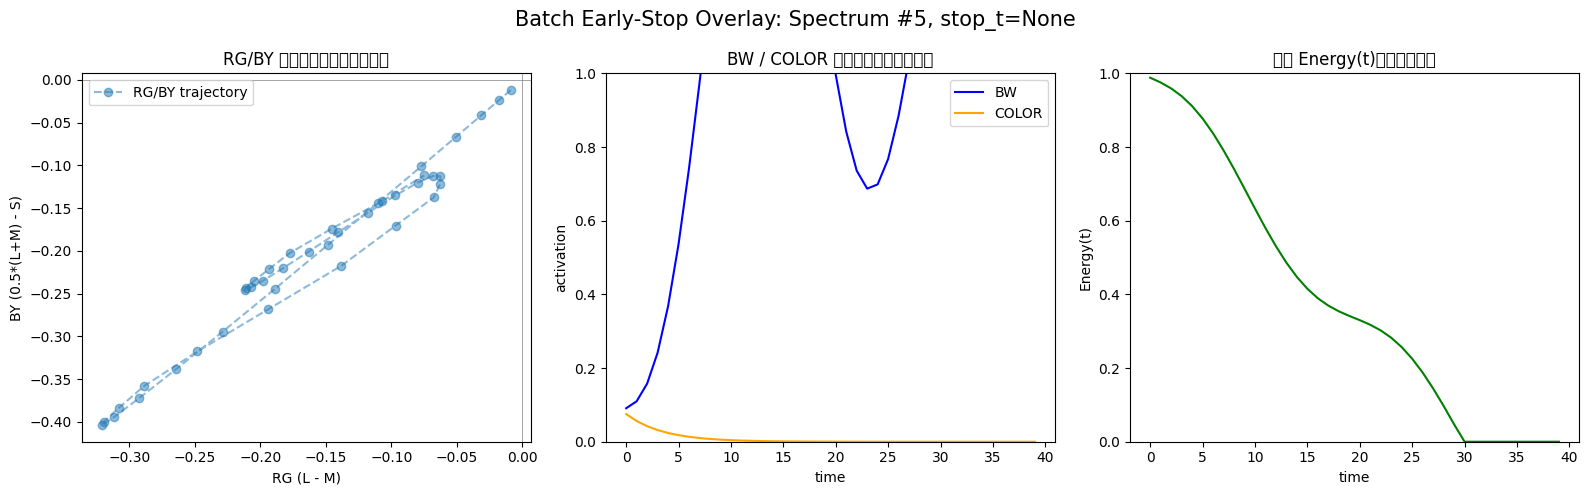

[Done] Spectrum 5/12, stop_t = None



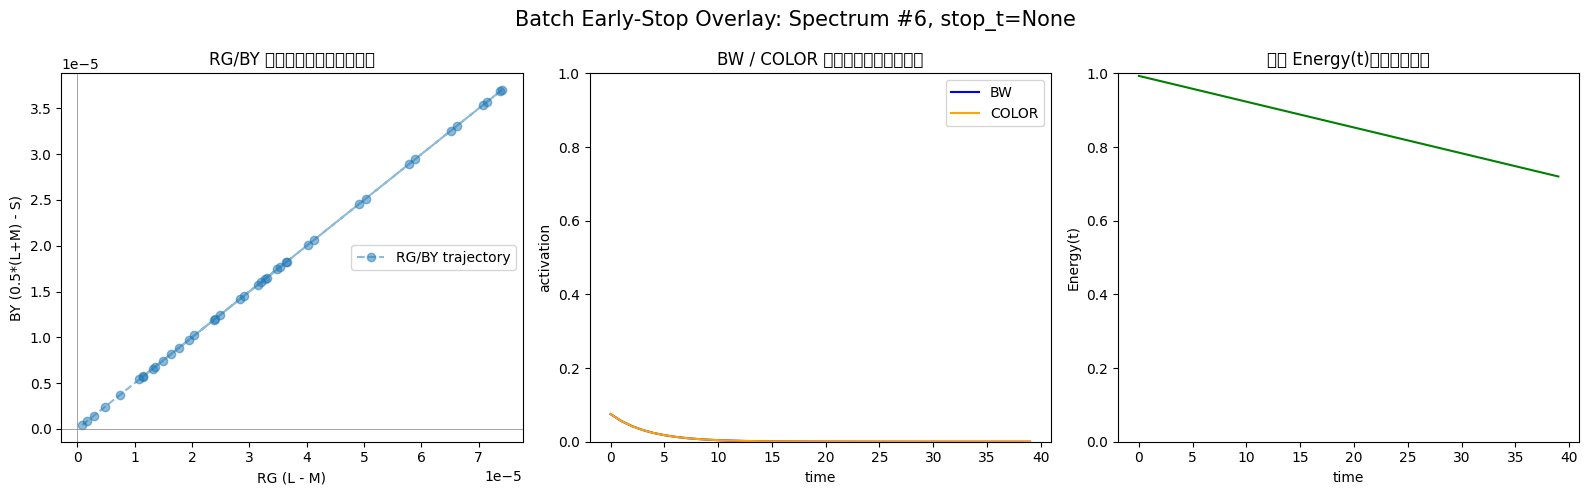

[Done] Spectrum 6/12, stop_t = None

[Soft-Gate] Terminated at t = 7  (F = 0.1349)


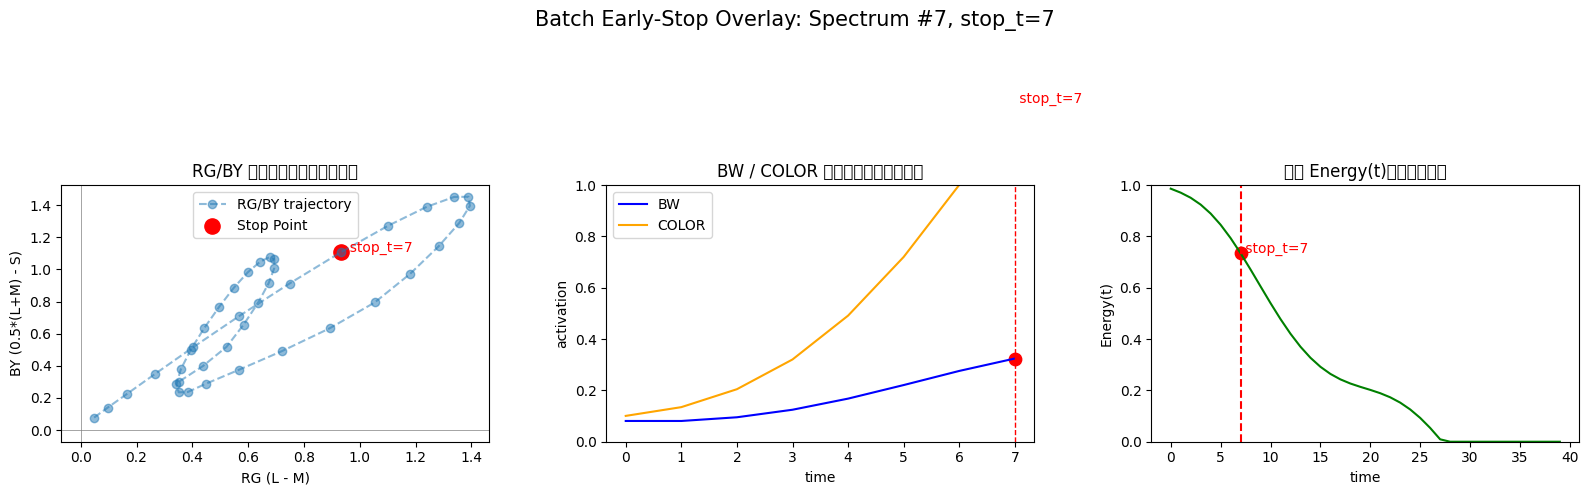

[Done] Spectrum 7/12, stop_t = 7



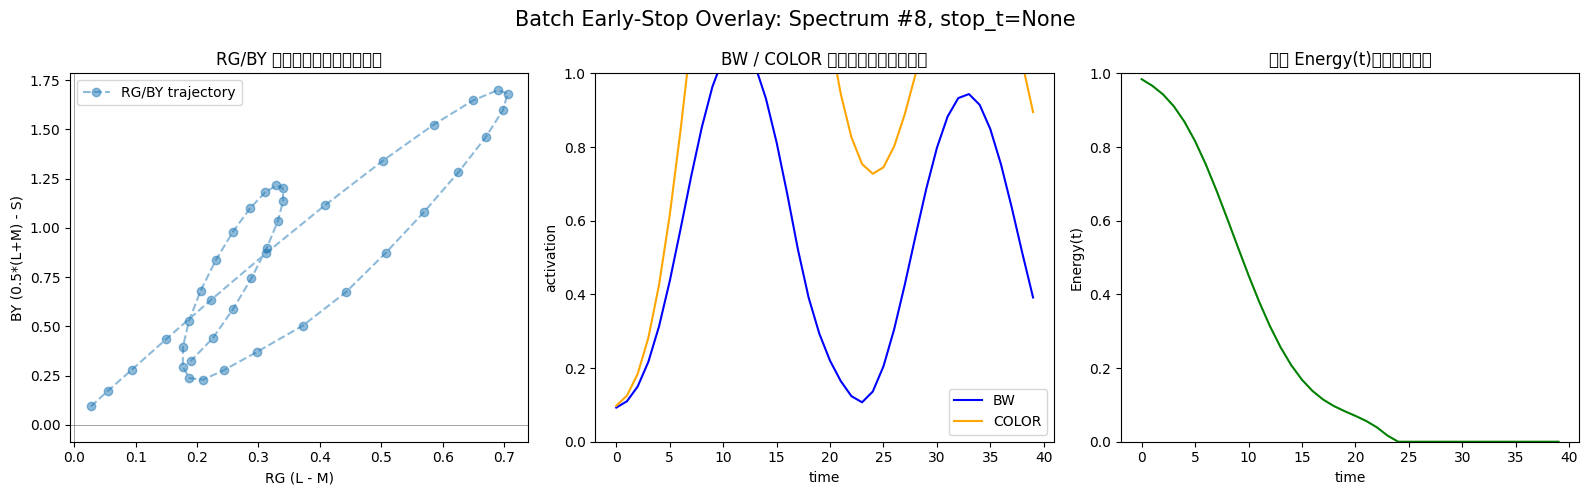

[Done] Spectrum 8/12, stop_t = None

[Soft-Gate] Terminated at t = 19  (F = 0.1427)


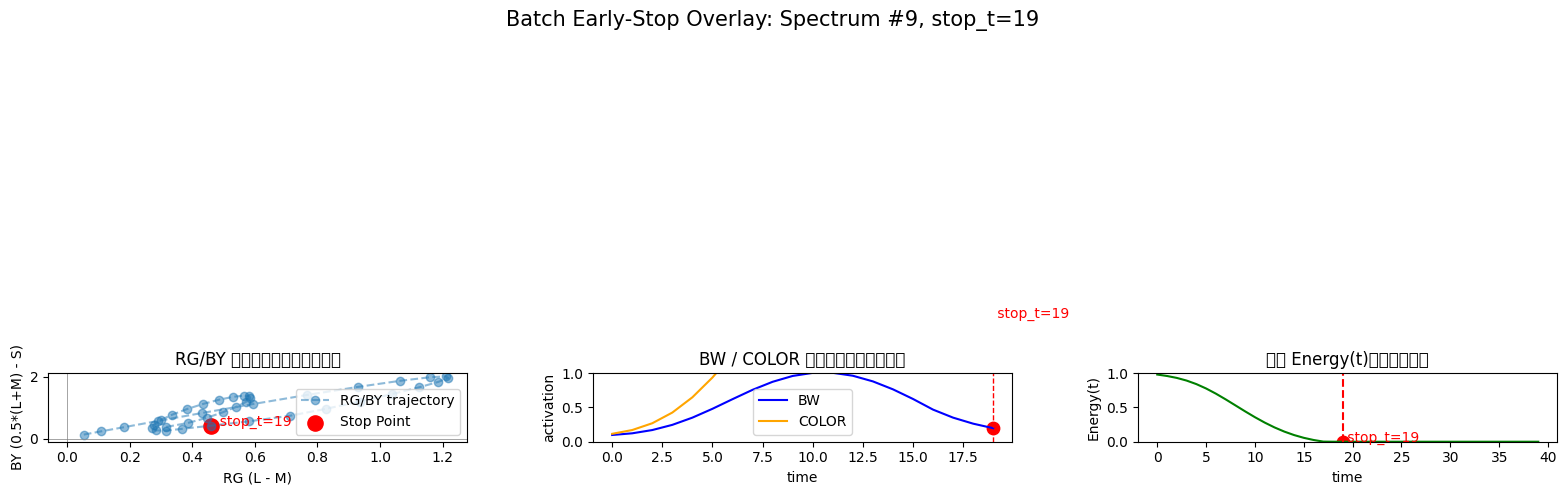

[Done] Spectrum 9/12, stop_t = 19



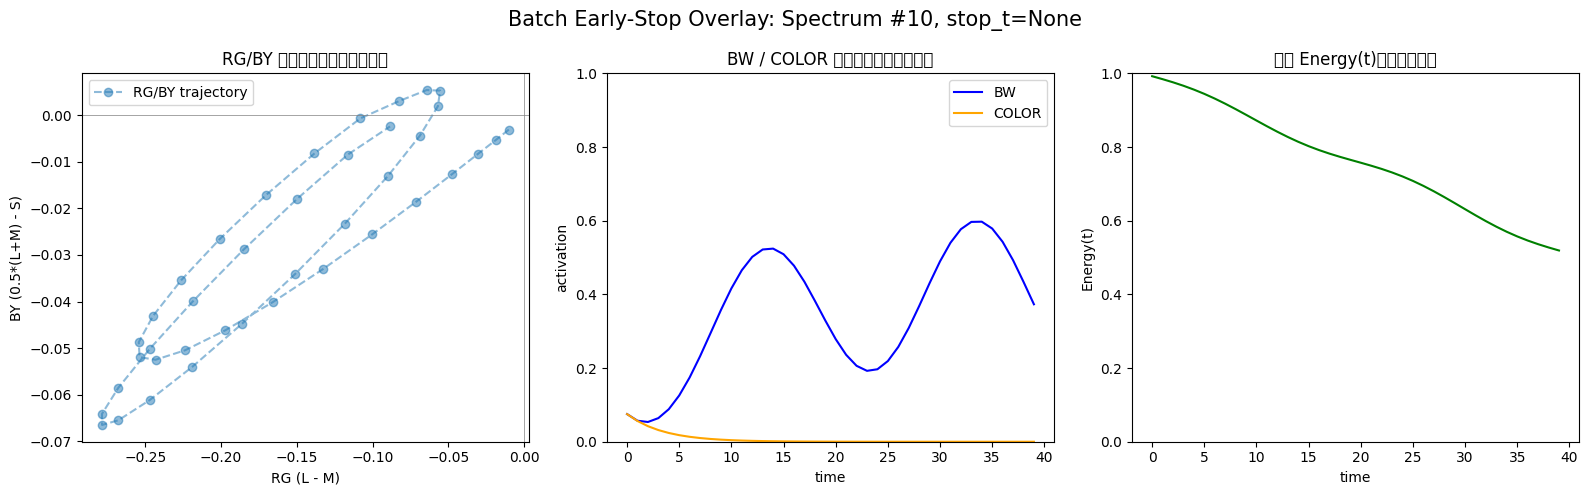

[Done] Spectrum 10/12, stop_t = None

[Soft-Gate] Terminated at t = 3  (F = 0.1477)


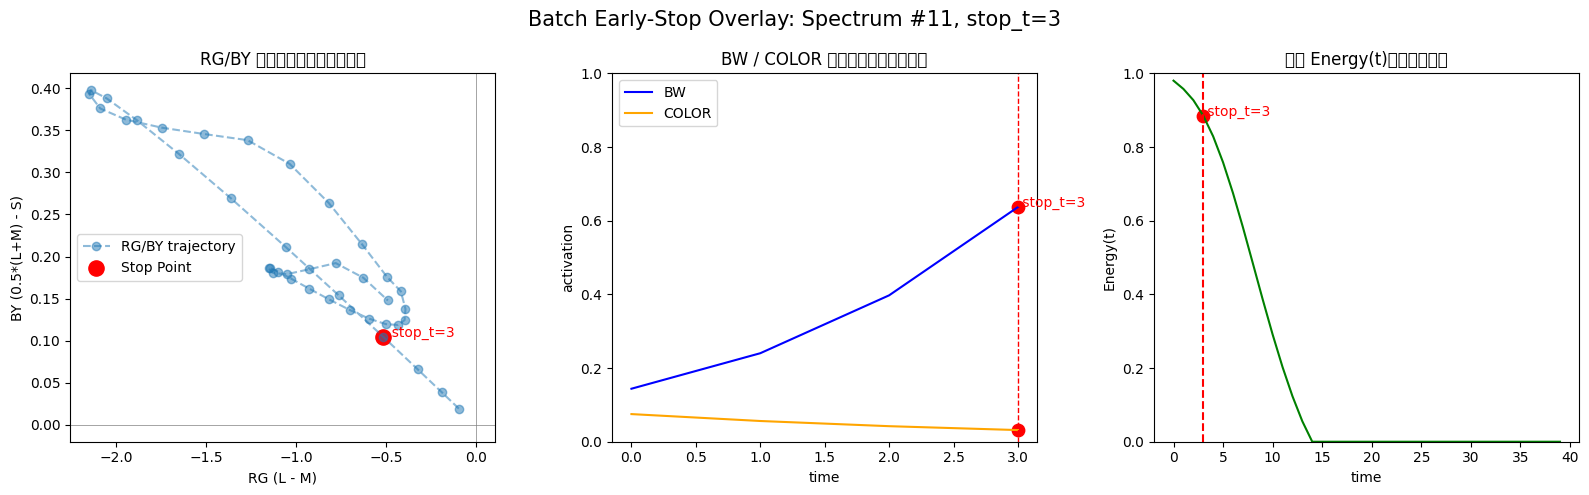

[Done] Spectrum 11/12, stop_t = 3



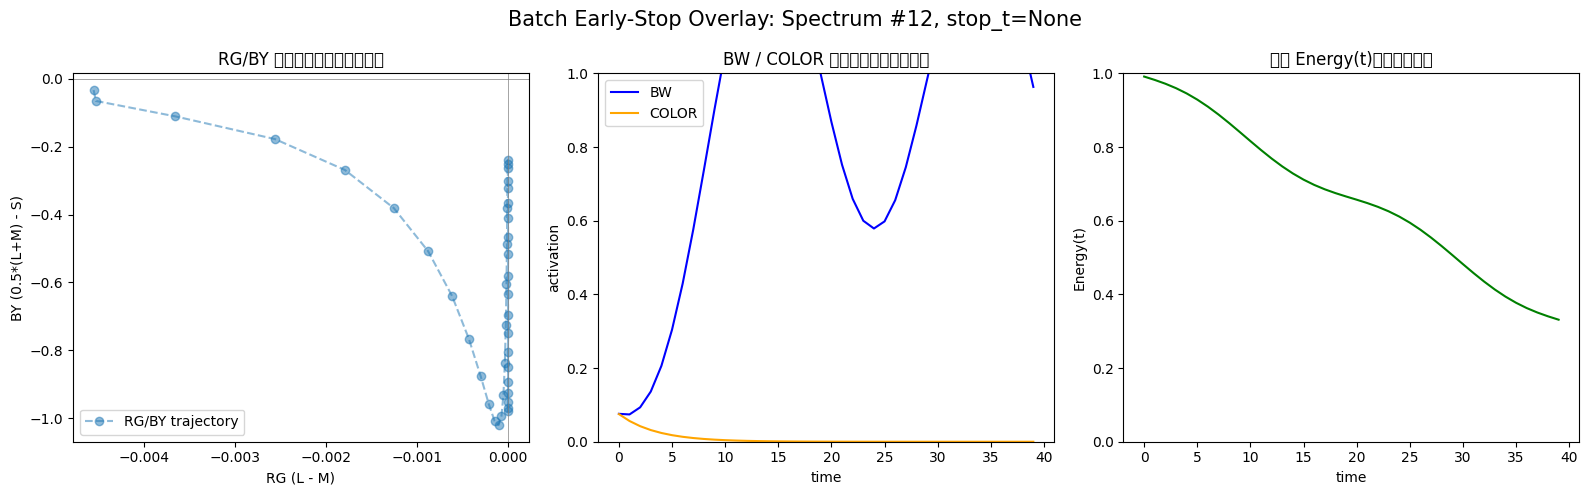

[Done] Spectrum 12/12, stop_t = None

Cell 12 OK — Batch early-stop overlay completed.


In [12]:
# ================================================================
# Cell 12 — Batch Early-Stop Overlay for All Spectra
# ================================================================
import numpy as np
import matplotlib.pyplot as plt

def batch_plot_earlystop(
    N=12,
    T=40,
    use_energy_noise=False,
    title_prefix="Batch Early-Stop Overlay"
):
    """
    对 N 个光谱分别运行 pipeline 并生成独立的 Cell 11 三联图。
    """

    phase_gate = make_phase_gate(T=T)

    for i in range(N):
        # --- 生成光谱（与 Cell 10 完全一致） ---
        spec = generate_random_spectrum()

        # --- 跑 pipeline ---
        RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_values, stop_t = \
            run_energy_pipeline(
                spec,
                receptor_sens,
                wavelengths,
                T=T,
                gate=phase_gate,
                use_energy_noise=use_energy_noise
            )

        # --- 画三联图 ---
        plot_with_earlystop_overlay(
            RG, BY,
            BW, COLOR,
            Energy_ts,
            stop_t,
            title=f"{title_prefix}: Spectrum #{i+1}, stop_t={stop_t}"
        )

        print(f"[Done] Spectrum {i+1}/{N}, stop_t = {stop_t}\n")


# ============================
# 运行批量绘图
# ============================
batch_plot_earlystop(N=12, T=40)
print("Cell 12 OK — Batch early-stop overlay completed.")

In [13]:
# ================================================================
# Cell 13 — Automatic Semantic Maturity Scoring + Table Output
# ================================================================
import numpy as np

def compute_semantic_score(BW, COLOR, stop_t):
    """
    输出 ∈ [0, 1] 的 semantic maturity score
    """

    T = len(COLOR)
    if stop_t is None:
        stop_t = T - 1

    # --- 1. 颜色主导度（COLOR > BW 程度） ---
    dominance = np.clip((COLOR[stop_t] - BW[stop_t]), 0, 1)

    # --- 2. COLOR 稳态程度（局部斜率接近 0） ---
    if stop_t >= 2:
        slope = abs(COLOR[stop_t] - COLOR[stop_t - 1])
        stability = np.clip(1 - 5 * slope, 0, 1)
    else:
        stability = 0

    # --- 3. 单调性检测：检查过去几步是否单调上升 ---
    window = COLOR[max(0, stop_t - 4): stop_t + 1]
    monotonic = np.all(np.diff(window) >= -0.02)  # 微弱震荡容忍
    monotonicity = 1.0 if monotonic else 0.3

    # --- 综合得分 ---
    score = (
        dominance * 0.4 +
        stability * 0.4 +
        monotonicity * 0.2
    )
    return float(np.clip(score, 0, 1))


# ================================================================
# 批量测试 + 输出 TSV 表格
# ================================================================
def batch_semantic_table(N=30, T=40, use_energy_noise=False):
    phase_gate = make_phase_gate(T=T)

    print("id\tstop_t\tcolor_end\tbw_end\tsemantic_score")

    for i in range(N):
        spec = generate_random_spectrum()

        RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_values, stop_t = \
            run_energy_pipeline(
                spec,
                receptor_sens,
                wavelengths,
                T=T,
                gate=phase_gate,
                use_energy_noise=use_energy_noise
            )

        if stop_t is None:
            stop_t = len(COLOR) - 1

        score = compute_semantic_score(BW, COLOR, stop_t)

        # TSV 机读输出
        print(f"{i+1}\t{stop_t}\t{COLOR[stop_t]:.4f}\t{BW[stop_t]:.4f}\t{score:.4f}")

    print("\nCell 13 OK — Semantic table generated.")


# ================================================================
# 运行 Cell 13，生成表格
# ================================================================
batch_semantic_table(N=30, T=40)

id	stop_t	color_end	bw_end	semantic_score
1	39	0.7935	0.0000	0.5782
[Soft-Gate] Terminated at t = 5  (F = 0.1416)
2	5	0.0178	0.8088	0.5881
3	39	0.1686	1.0677	0.3476
[Soft-Gate] Terminated at t = 7  (F = 0.1374)
4	7	0.0100	1.0698	0.5933
[Soft-Gate] Terminated at t = 7  (F = 0.1322)
5	7	0.0100	1.0604	0.5933
[Soft-Gate] Terminated at t = 5  (F = 0.1437)
6	5	0.0178	0.7995	0.5881
7	39	0.0845	0.9030	0.4037
[Soft-Gate] Terminated at t = 3  (F = 0.1361)
8	3	0.0316	0.6724	0.5789
9	39	0.0619	0.8675	0.4187
[Soft-Gate] Terminated at t = 3  (F = 0.1272)
10	3	0.0316	0.7127	0.5789
11	39	0.0081	0.9079	0.5946
[Soft-Gate] Terminated at t = 5  (F = 0.1481)
12	5	0.0178	0.7645	0.5881
13	39	0.0000	0.4579	0.6000
[Soft-Gate] Terminated at t = 6  (F = 0.1451)
14	6	0.0133	0.8741	0.5911
[Soft-Gate] Terminated at t = 6  (F = 0.1340)
15	6	0.0133	0.9113	0.5911
16	39	0.0000	0.3975	0.6000
[Soft-Gate] Terminated at t = 5  (F = 0.1344)
17	5	0.0178	0.8406	0.5881
[Soft-Gate] Terminated at t = 7  (F = 0.1408)
18	7	0.0100	

[Soft-Gate] Terminated at t = 5  (F = 0.1149)
[Soft-Gate] Terminated at t = 4  (F = 0.1385)
[Soft-Gate] Terminated at t = 6  (F = 0.1424)
[Soft-Gate] Terminated at t = 6  (F = 0.1316)
[Soft-Gate] Terminated at t = 5  (F = 0.1068)
[Soft-Gate] Terminated at t = 5  (F = 0.1298)
[Soft-Gate] Terminated at t = 4  (F = 0.1430)
[Soft-Gate] Terminated at t = 4  (F = 0.1060)
[Soft-Gate] Terminated at t = 7  (F = 0.1477)
[Soft-Gate] Terminated at t = 3  (F = 0.1319)
[Soft-Gate] Terminated at t = 5  (F = 0.1292)
[Soft-Gate] Terminated at t = 6  (F = 0.1440)
[Soft-Gate] Terminated at t = 6  (F = 0.1227)
[Soft-Gate] Terminated at t = 5  (F = 0.1173)
[Soft-Gate] Terminated at t = 4  (F = 0.0997)
[Soft-Gate] Terminated at t = 6  (F = 0.1360)
[Soft-Gate] Terminated at t = 5  (F = 0.1283)
[Soft-Gate] Terminated at t = 6  (F = 0.1437)
[Soft-Gate] Terminated at t = 6  (F = 0.1217)
[Soft-Gate] Terminated at t = 7  (F = 0.1424)
[Soft-Gate] Terminated at t = 5  (F = 0.1334)
[Soft-Gate] Terminated at t = 7  (

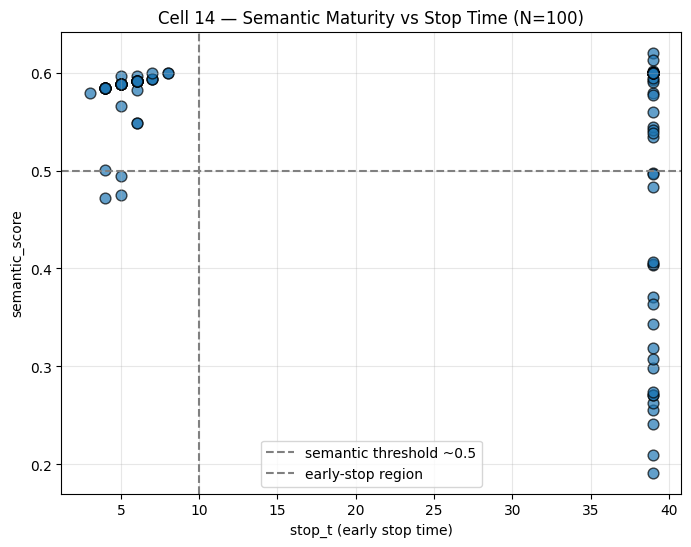

Cell 14 OK — Scatter plot generated.
Mean semantic score = 0.533
Mean stop_t = 21.51


In [14]:
# ================================================================
# Cell 14 — Semantic Maturity vs Stop Time (N=100, Fully Independent)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 重新定义 make_phase_gate（来自 Cell 9，确保本 cell 独立可用）
# ------------------------------------------------------------
def make_phase_gate(T=40, freq=1.0, phase=0.0):
    """
    gate(t) = sin^2(2π * freq * (t/T) + phase)
    并归一化到 [0.1, 1.0]
    """
    t = np.arange(T)
    raw = np.sin(2 * np.pi * (freq * t / T) + phase) ** 2

    raw_min, raw_max = raw.min(), raw.max()
    if raw_max - raw_min < 1e-12:
        norm = np.ones(T)
    else:
        norm = (raw - raw_min) / (raw_max - raw_min)

    gate = 0.1 + 0.9 * norm
    return gate


# ------------------------------------------------------------
# 提醒：compute_semantic_score 已在 Cell 13 定义
#       若你开了新 session，则需先运行 Cell 13 再运行本 cell
# ------------------------------------------------------------


# ------------------------------------------------------------
# 主函数：批量计算并绘制散点图
# ------------------------------------------------------------
def batch_semantic_scatter(N=100, T=40, use_energy_noise=False):
    phase_gate = make_phase_gate(T=T)

    stop_list = []
    score_list = []

    for i in range(N):
        spec = generate_random_spectrum()

        RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_values, stop_t = \
            run_energy_pipeline(
                spec,
                receptor_sens,
                wavelengths,
                T=T,
                gate=phase_gate,
                use_energy_noise=use_energy_noise
            )

        if stop_t is None:
            stop_t = len(COLOR) - 1

        score = compute_semantic_score(BW, COLOR, stop_t)

        stop_list.append(stop_t)
        score_list.append(score)

    stop_list = np.array(stop_list)
    score_list = np.array(score_list)

    # ------------------ 绘制散点图 ------------------
    plt.figure(figsize=(8, 6))
    plt.scatter(stop_list, score_list, s=60, alpha=0.7, edgecolor='black')

    plt.xlabel("stop_t (early stop time)")
    plt.ylabel("semantic_score")
    plt.title("Cell 14 — Semantic Maturity vs Stop Time (N=100)")

    plt.axhline(0.5, color='gray', linestyle='--', label='semantic threshold ~0.5')
    plt.axvline(10, color='gray', linestyle='--', label='early-stop region')

    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print("Cell 14 OK — Scatter plot generated.")
    print(f"Mean semantic score = {score_list.mean():.3f}")
    print(f"Mean stop_t = {stop_list.mean():.2f}")


# ============================
# 执行 N = 100
# ============================
batch_semantic_scatter(N=100, T=40)

[Soft-Gate] Terminated at t = 5  (F = 0.1125)
[Soft-Gate] Terminated at t = 4  (F = 0.1350)
[Soft-Gate] Terminated at t = 6  (F = 0.1199)
[Soft-Gate] Terminated at t = 6  (F = 0.1414)
[Soft-Gate] Terminated at t = 4  (F = 0.0985)
[Soft-Gate] Terminated at t = 5  (F = 0.1372)
[Soft-Gate] Terminated at t = 3  (F = 0.1471)
[Soft-Gate] Terminated at t = 6  (F = 0.1193)
[Soft-Gate] Terminated at t = 3  (F = 0.1148)
[Soft-Gate] Terminated at t = 6  (F = 0.1403)
[Soft-Gate] Terminated at t = 5  (F = 0.1290)
[Soft-Gate] Terminated at t = 6  (F = 0.1286)
[Soft-Gate] Terminated at t = 7  (F = 0.1410)
[Soft-Gate] Terminated at t = 6  (F = 0.1457)
[Soft-Gate] Terminated at t = 6  (F = 0.1199)
[Soft-Gate] Terminated at t = 4  (F = 0.1370)
[Soft-Gate] Terminated at t = 7  (F = 0.1358)
[Soft-Gate] Terminated at t = 4  (F = 0.1301)
[Soft-Gate] Terminated at t = 5  (F = 0.1250)
[Soft-Gate] Terminated at t = 7  (F = 0.1287)
[Soft-Gate] Terminated at t = 5  (F = 0.1345)
[Soft-Gate] Terminated at t = 6  (

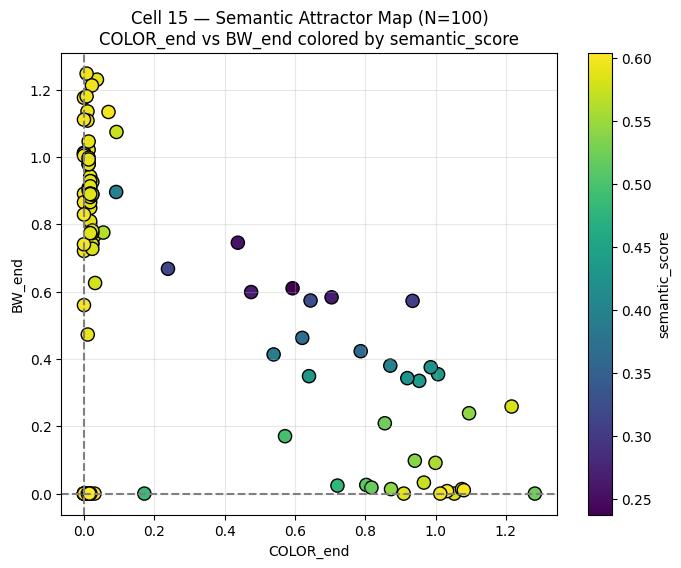

Cell 15 OK — Semantic Attractor Map generated.
Average semantic score: 0.544
Average stop_t: 22.86


In [15]:
# ================================================================
# Cell 15 — Semantic Attractor Map (COLOR_end vs BW_end)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt

def batch_semantic_attractor_map(N=100, T=40, use_energy_noise=False):
    phase_gate = make_phase_gate(T=T)

    color_ends = []
    bw_ends = []
    scores = []
    stops = []

    for i in range(N):
        spec = generate_random_spectrum()

        RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_values, stop_t = \
            run_energy_pipeline(
                spec,
                receptor_sens,
                wavelengths,
                T=T,
                gate=phase_gate,
                use_energy_noise=use_energy_noise
            )

        # 处理 stop_t = None
        if stop_t is None:
            stop_t = len(COLOR) - 1

        color_end = COLOR[stop_t]
        bw_end = BW[stop_t]
        score = compute_semantic_score(BW, COLOR, stop_t)

        color_ends.append(color_end)
        bw_ends.append(bw_end)
        scores.append(score)
        stops.append(stop_t)

    color_ends = np.array(color_ends)
    bw_ends = np.array(bw_ends)
    scores = np.array(scores)
    stops = np.array(stops)

    # =========== 绘制语义吸引子图 ============
    plt.figure(figsize=(8, 6))

    # 用 semantic_score 着色
    plt.scatter(
        color_ends,
        bw_ends,
        c=scores,
        cmap='viridis',
        s=90,
        edgecolor='black'
    )

    plt.xlabel("COLOR_end")
    plt.ylabel("BW_end")
    plt.title("Cell 15 — Semantic Attractor Map (N=100)\nCOLOR_end vs BW_end colored by semantic_score")
    plt.colorbar(label="semantic_score")

    plt.axhline(0, color='gray', linestyle='--')
    plt.axvline(0, color='gray', linestyle='--')

    plt.grid(alpha=0.3)
    plt.show()

    print("Cell 15 OK — Semantic Attractor Map generated.")
    print(f"Average semantic score: {scores.mean():.3f}")
    print(f"Average stop_t: {stops.mean():.2f}")


# ======================
# Run Cell 15
# ======================
batch_semantic_attractor_map(N=100, T=40)

[Soft-Gate] Terminated at t = 5  (F = 0.1430)
[Soft-Gate] Terminated at t = 5  (F = 0.1476)
[Soft-Gate] Terminated at t = 4  (F = 0.1097)
[Soft-Gate] Terminated at t = 6  (F = 0.1380)
[Soft-Gate] Terminated at t = 4  (F = 0.1392)
[Soft-Gate] Terminated at t = 4  (F = 0.1426)
[Soft-Gate] Terminated at t = 6  (F = 0.1177)
[Soft-Gate] Terminated at t = 4  (F = 0.1457)
[Soft-Gate] Terminated at t = 6  (F = 0.1204)
[Soft-Gate] Terminated at t = 6  (F = 0.1206)
[Soft-Gate] Terminated at t = 6  (F = 0.1371)
[Soft-Gate] Terminated at t = 5  (F = 0.1377)
[Soft-Gate] Terminated at t = 7  (F = 0.1317)
[Soft-Gate] Terminated at t = 4  (F = 0.1307)
[Soft-Gate] Terminated at t = 5  (F = 0.1252)
[Soft-Gate] Terminated at t = 5  (F = 0.1131)
[Soft-Gate] Terminated at t = 5  (F = 0.1028)
[Soft-Gate] Terminated at t = 4  (F = 0.1474)
[Soft-Gate] Terminated at t = 4  (F = 0.1288)
[Soft-Gate] Terminated at t = 4  (F = 0.1246)
[Soft-Gate] Terminated at t = 4  (F = 0.0992)
[Soft-Gate] Terminated at t = 8  (

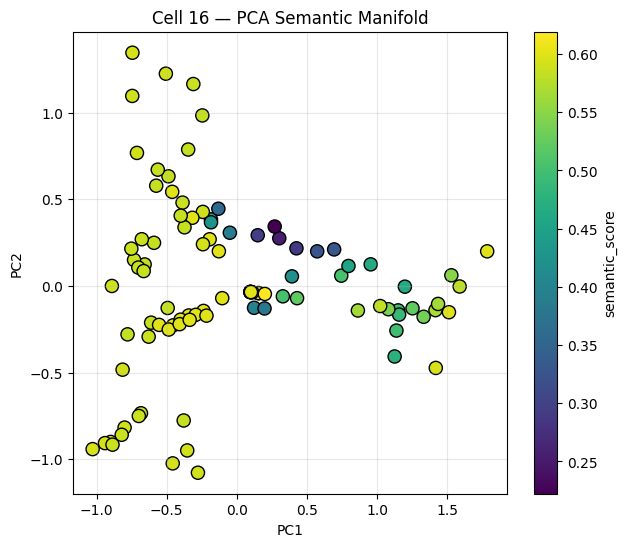

PCA explained variance: [0.53382832 0.23772221]


c:\Users\cheny\anaconda3\envs\vtdc\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


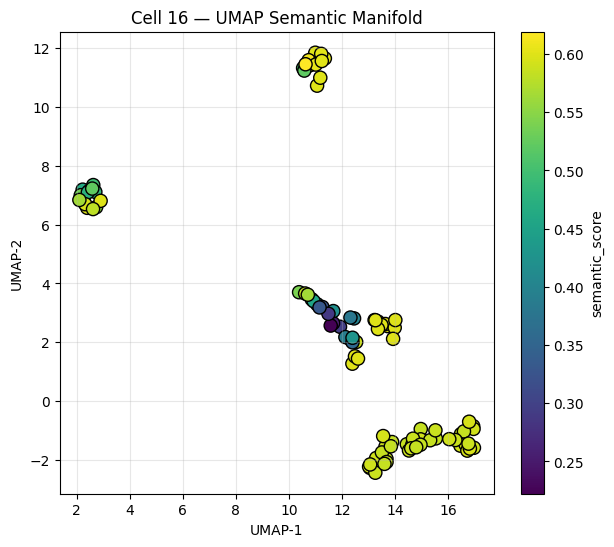

Cell 16 OK — Semantic Manifold generated.


In [16]:
# ================================================================
# Cell 16 — Semantic Manifold (UMAP + PCA)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# 如果未安装 UMAP，可以通过 pip 安装：
# pip install umap-learn
import umap

def batch_collect_semantic_vectors(N=100, T=40, use_energy_noise=False):
    """
    为每条光谱抽取高维语义向量：
    [COLOR_end, BW_end, RG_end, BY_end, Energy_end]
    """
    phase_gate = make_phase_gate(T=T)

    semantic_vectors = []
    scores = []
    stops = []

    for i in range(N):
        spec = generate_random_spectrum()

        RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_values, stop_t = \
            run_energy_pipeline(
                spec,
                receptor_sens,
                wavelengths,
                T=T,
                gate=phase_gate,
                use_energy_noise=use_energy_noise
            )

        # Handle stop_t
        if stop_t is None:
            stop_t = len(COLOR) - 1

        # Extract semantic vector
        v = np.array([
            COLOR[stop_t],
            BW[stop_t],
            RG[stop_t],
            BY[stop_t],
            Energy_ts[stop_t]
        ])

        semantic_vectors.append(v)

        # Semantic maturity score
        score = compute_semantic_score(BW, COLOR, stop_t)
        scores.append(score)
        stops.append(stop_t)

    return np.array(semantic_vectors), np.array(scores), np.array(stops)


# ================================================================
# PCA Plot
# ================================================================
def plot_pca_semantic_map(vecs, scores):
    pca = PCA(n_components=2)
    pca_2d = pca.fit_transform(vecs)

    plt.figure(figsize=(7,6))
    plt.scatter(
        pca_2d[:,0],
        pca_2d[:,1],
        c=scores,
        cmap='viridis',
        s=90,
        edgecolor='black'
    )
    plt.title("Cell 16 — PCA Semantic Manifold")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar(label="semantic_score")
    plt.grid(alpha=0.3)
    plt.show()

    print("PCA explained variance:", pca.explained_variance_ratio_)


# ================================================================
# UMAP Plot
# ================================================================
def plot_umap_semantic_map(vecs, scores):
    reducer = umap.UMAP(
        n_neighbors=20,
        min_dist=0.1,
        metric='euclidean',
        random_state=42
    )

    umap_2d = reducer.fit_transform(vecs)

    plt.figure(figsize=(7,6))
    plt.scatter(
        umap_2d[:,0],
        umap_2d[:,1],
        c=scores,
        cmap='viridis',
        s=90,
        edgecolor='black'
    )

    plt.title("Cell 16 — UMAP Semantic Manifold")
    plt.xlabel("UMAP-1")
    plt.ylabel("UMAP-2")
    plt.colorbar(label="semantic_score")
    plt.grid(alpha=0.3)
    plt.show()


# ================================================================
# Run Cell 16
# ================================================================
vecs, scores, stops = batch_collect_semantic_vectors(N=100, T=40)

print("Cell 16 — semantic vectors collected:", vecs.shape)

plot_pca_semantic_map(vecs, scores)
plot_umap_semantic_map(vecs, scores)

print("Cell 16 OK — Semantic Manifold generated.")

In [17]:
# ================================================================
# Cell 17 — Perceptual Onset Detection (Semantic / Curvature / Manifold)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

# ----------------------------------------------------------
# 1. Semantic Onset: COLOR - BW 分化达到某个阈值
# ----------------------------------------------------------
def detect_semantic_onset(BW, COLOR, theta=0.05):
    diff = np.abs(COLOR - BW)
    onset_points = np.where(diff > theta)[0]
    return int(onset_points[0]) if len(onset_points) > 0 else None


# ----------------------------------------------------------
# 2. Curvature Onset: COLOR-BW 二阶导数出现稳定方向
# ----------------------------------------------------------
def detect_curvature_onset(BW, COLOR, window=3, slope_thresh=0.02):
    diff = COLOR - BW
    d1 = np.diff(diff)
    d2 = np.diff(d1)  # curvature

    for t in range(window, len(d2)):
        window_slice = d2[t-window:t]
        if np.all(np.abs(window_slice) < slope_thresh):
            return t
    return None


# ----------------------------------------------------------
# 3. Manifold Entry Onset: 接近吸引子（使用 KNN）
# ----------------------------------------------------------
def detect_manifold_entry(vec_seq, attractor_points, k=5, dist_cutoff=0.3):
    """
    vec_seq: 每个时间点的高维向量
    attractor_points: 来自 Cell 16 的 attractor 区域点
    """
    nbrs = NearestNeighbors(n_neighbors=k).fit(attractor_points)

    for t in range(len(vec_seq)):
        dist, _ = nbrs.kneighbors([vec_seq[t]])
        if np.mean(dist) < dist_cutoff:
            return t
    return None


# ----------------------------------------------------------
# 主函数：对一条光谱执行 onset detection
# ----------------------------------------------------------
def compute_onsets_for_spectrum(spec, T=40):
    phase_gate = make_phase_gate(T=T)

    RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_vals, stop_t = \
        run_energy_pipeline(
            spec,
            receptor_sens,
            wavelengths,
            T=T,
            gate=phase_gate,
            use_energy_noise=False
        )

    if stop_t is None:
        stop_t = len(COLOR) - 1

    # 构建时间序列语义向量
    vec_seq = np.stack([
        COLOR, BW, RG, BY, Energy_ts
    ], axis=1)

    # 使用最高语义区的 attractor 点
    # 这里取 COLOR_end > 0.5 or BW_end > 0.5 的作为吸引子候选
    attractor_indices = np.where((COLOR > 0.5) | (BW > 0.5))[0]
    attractor_points = vec_seq[attractor_indices] if len(attractor_indices) > 5 else vec_seq[-5:]

    # 三类 onset
    onset_sem = detect_semantic_onset(BW, COLOR)
    onset_curv = detect_curvature_onset(BW, COLOR)
    onset_mani = detect_manifold_entry(vec_seq, attractor_points)

    return onset_sem, onset_curv, onset_mani, stop_t


# ----------------------------------------------------------
# 批量运行并生成表格 + 可视化
# ----------------------------------------------------------
def batch_onset_analysis(N=30, T=40):
    onset_sem_list = []
    onset_curv_list = []
    onset_mani_list = []
    stop_list = []

    for i in range(N):
        spec = generate_random_spectrum()

        o1, o2, o3, stop_t = compute_onsets_for_spectrum(spec, T=T)

        onset_sem_list.append(o1)
        onset_curv_list.append(o2)
        onset_mani_list.append(o3)
        stop_list.append(stop_t)

        print(f"[{i+1}] sem={o1}, curv={o2}, mani={o3}, stop={stop_t}")

    # -------- 可视化散点图 --------
    plt.figure(figsize=(8,6))
    plt.scatter(stop_list, onset_sem_list, c='red', label='semantic onset', s=70)
    plt.scatter(stop_list, onset_curv_list, c='blue', label='curvature onset', s=70)
    plt.scatter(stop_list, onset_mani_list, c='green', label='manifold onset', s=70)

    plt.xlabel("stop_t")
    plt.ylabel("onset time")
    plt.title("Cell 17 — Perceptual Onset vs stop_t")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print("\nCell 17 OK — Perceptual onset analysis completed.")


# =======================
# Run for N = 30
# =======================
batch_onset_analysis(N=30)

[Soft-Gate] Terminated at t = 7  (F = 0.1472)


ValueError: all input arrays must have the same shape

[Soft-Gate] Terminated at t = 6  (F = 0.1480)
[1] sem=1, curv=None, mani=None, stop=6
[Soft-Gate] Terminated at t = 4  (F = 0.1234)
[2] sem=0, curv=None, mani=None, stop=4
[3] sem=3, curv=3, mani=8, stop=39
[Soft-Gate] Terminated at t = 3  (F = 0.1481)
[4] sem=0, curv=None, mani=None, stop=3
[Soft-Gate] Terminated at t = 4  (F = 0.1443)
[5] sem=1, curv=None, mani=None, stop=4
[6] sem=4, curv=3, mani=10, stop=39
[Soft-Gate] Terminated at t = 5  (F = 0.1291)
[7] sem=1, curv=None, mani=None, stop=5
[8] sem=3, curv=11, mani=11, stop=39
[Soft-Gate] Terminated at t = 3  (F = 0.1332)
[9] sem=0, curv=None, mani=None, stop=3
[Soft-Gate] Terminated at t = 6  (F = 0.1372)
[10] sem=1, curv=None, mani=None, stop=6
[11] sem=4, curv=3, mani=9, stop=39
[Soft-Gate] Terminated at t = 6  (F = 0.1176)
[12] sem=1, curv=None, mani=None, stop=6
[Soft-Gate] Terminated at t = 5  (F = 0.1061)
[13] sem=1, curv=None, mani=None, stop=5
[Soft-Gate] Terminated at t = 5  (F = 0.1460)
[14] sem=1, curv=None, mani=None,

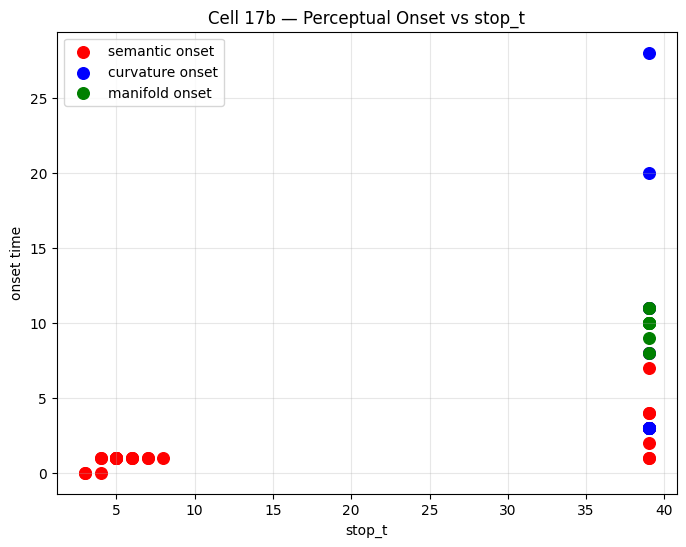


Cell 17b OK — Robust perceptual onset analysis completed.


In [18]:
# ================================================================
# Cell 17b — Perceptual Onset Detection (Robust to Early-Stop)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors


# ----------------------------------------------------------
# 1. Semantic Onset
# ----------------------------------------------------------
def detect_semantic_onset(BW, COLOR, theta=0.05):
    diff = np.abs(COLOR - BW)
    onset_points = np.where(diff > theta)[0]
    return int(onset_points[0]) if len(onset_points) > 0 else None


# ----------------------------------------------------------
# 2. Curvature Onset（COLOR-BW 的二阶导）
# ----------------------------------------------------------
def detect_curvature_onset(BW, COLOR, window=3, slope_thresh=0.02):
    diff = COLOR - BW
    if len(diff) < 4:
        return None

    d1 = np.diff(diff)
    d2 = np.diff(d1)

    # 在稳定绝对值小的区域视为“收敛”
    for t in range(window, len(d2)):
        window_slice = d2[t-window:t]
        if np.all(np.abs(window_slice) < slope_thresh):
            return t
    return None


# ----------------------------------------------------------
# 3. Manifold Onset（KNN 距离）
# ----------------------------------------------------------
def detect_manifold_entry(vec_seq, attractor_points, k=5, dist_cutoff=0.25):
    if len(attractor_points) < k:
        # 异常情况：吸引子点太少
        return None

    nbrs = NearestNeighbors(n_neighbors=k).fit(attractor_points)

    for t in range(len(vec_seq)):
        dist, _ = nbrs.kneighbors([vec_seq[t]])
        if np.mean(dist) < dist_cutoff:
            return t
    return None


# ----------------------------------------------------------
# 对单一光谱做 onset 分析
# ----------------------------------------------------------
def compute_onsets_for_spectrum(spec, T=40):
    phase_gate = make_phase_gate(T=T)

    RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_vals, stop_t = \
        run_energy_pipeline(
            spec,
            receptor_sens,
            wavelengths,
            T=T,
            gate=phase_gate,
            use_energy_noise=False
        )

    if stop_t is None:
        stop_t = len(COLOR) - 1

    # ------------------------------
    # ✔ 关键修复：统一序列长度到 stop_t
    # ------------------------------
    BW = BW[:stop_t+1]
    COLOR = COLOR[:stop_t+1]
    RG = RG[:stop_t+1]
    BY = BY[:stop_t+1]
    Energy_ts = Energy_ts[:stop_t+1]

    # 构建时间语义向量
    vec_seq = np.stack([COLOR, BW, RG, BY, Energy_ts], axis=1)

    # 选择 attractor 区（COLOR 或 BW 较高即可）
    attractor_idx = np.where((COLOR > 0.5) | (BW > 0.5))[0]
    if len(attractor_idx) < 3:
        attractor_points = vec_seq[-3:]
    else:
        attractor_points = vec_seq[attractor_idx]

    onset_sem = detect_semantic_onset(BW, COLOR)
    onset_curv = detect_curvature_onset(BW, COLOR)
    onset_mani = detect_manifold_entry(vec_seq, attractor_points)

    return onset_sem, onset_curv, onset_mani, stop_t


# ----------------------------------------------------------
# 批量执行
# ----------------------------------------------------------
def batch_onset_analysis(N=30, T=40):
    onset_sem_list = []
    onset_curv_list = []
    onset_mani_list = []
    stop_list = []

    for i in range(N):
        spec = generate_random_spectrum()

        o1, o2, o3, stop_t = compute_onsets_for_spectrum(spec, T=T)
        onset_sem_list.append(o1)
        onset_curv_list.append(o2)
        onset_mani_list.append(o3)
        stop_list.append(stop_t)

        print(f"[{i+1}] sem={o1}, curv={o2}, mani={o3}, stop={stop_t}")

    # ----------------- 可视化 -----------------
    plt.figure(figsize=(8,6))
    plt.scatter(stop_list, onset_sem_list, c='red', label='semantic onset', s=70)
    plt.scatter(stop_list, onset_curv_list, c='blue', label='curvature onset', s=70)
    plt.scatter(stop_list, onset_mani_list, c='green', label='manifold onset', s=70)

    plt.xlabel("stop_t")
    plt.ylabel("onset time")
    plt.title("Cell 17b — Perceptual Onset vs stop_t")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    print("\nCell 17b OK — Robust perceptual onset analysis completed.")


# =========================
# 执行 N = 30
# =========================
batch_onset_analysis(N=30)

[Soft-Gate] Terminated at t = 5  (F = 0.1344)
[Soft-Gate] Terminated at t = 4  (F = 0.1063)
[Soft-Gate] Terminated at t = 5  (F = 0.1202)
[Soft-Gate] Terminated at t = 5  (F = 0.1257)
[Soft-Gate] Terminated at t = 6  (F = 0.1482)
[Soft-Gate] Terminated at t = 4  (F = 0.1065)
[Soft-Gate] Terminated at t = 5  (F = 0.1251)
[Soft-Gate] Terminated at t = 5  (F = 0.1362)
[Soft-Gate] Terminated at t = 6  (F = 0.1180)
[Soft-Gate] Terminated at t = 7  (F = 0.1300)
[Soft-Gate] Terminated at t = 7  (F = 0.1343)
[Soft-Gate] Terminated at t = 5  (F = 0.1377)
[Soft-Gate] Terminated at t = 7  (F = 0.1422)
[Soft-Gate] Terminated at t = 6  (F = 0.1232)
[Soft-Gate] Terminated at t = 4  (F = 0.1421)
[Soft-Gate] Terminated at t = 5  (F = 0.1391)
[Soft-Gate] Terminated at t = 6  (F = 0.1294)
[Soft-Gate] Terminated at t = 7  (F = 0.1380)
[Soft-Gate] Terminated at t = 3  (F = 0.1145)
[Soft-Gate] Terminated at t = 6  (F = 0.1209)
[Soft-Gate] Terminated at t = 4  (F = 0.1198)
[Soft-Gate] Terminated at t = 8  (

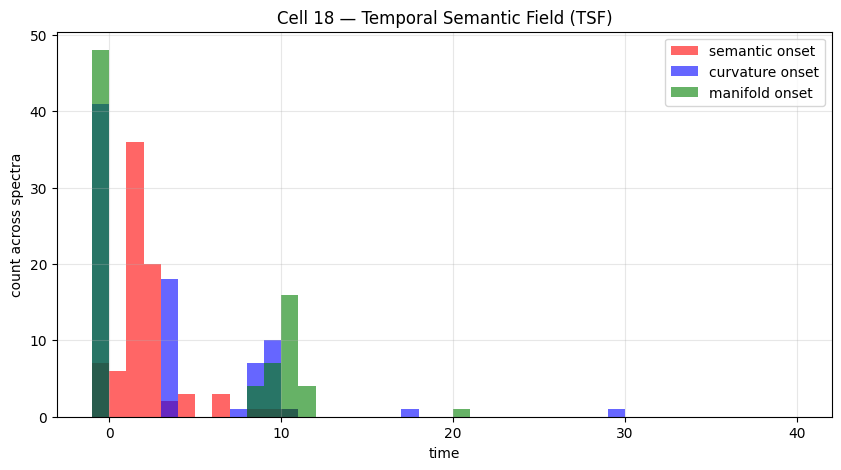

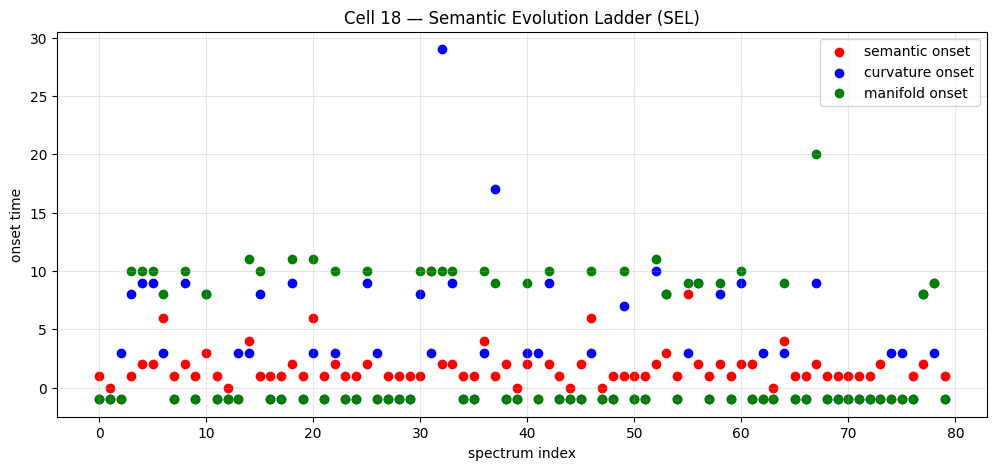

Cell 18 OK — Temporal Semantic Field + Semantic Evolution Ladder generated.


In [19]:
# ================================================================
# Cell 18 — Temporal Semantic Field (TSF)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------------------------------------
# 运行 batch_onset_analysis 但这次收集不绘图
# ----------------------------------------------------------
def collect_onset_data(N=80, T=40):
    onset_sem = []
    onset_curv = []
    onset_mani = []
    stop_ts = []

    for i in range(N):
        spec = generate_random_spectrum()

        o1, o2, o3, stop_t = compute_onsets_for_spectrum(spec, T=T)

        onset_sem.append(o1 if o1 is not None else -1)
        onset_curv.append(o2 if o2 is not None else -1)
        onset_mani.append(o3 if o3 is not None else -1)
        stop_ts.append(stop_t)

    return np.array(onset_sem), np.array(onset_curv), np.array(onset_mani), np.array(stop_ts)


# ----------------------------------------------------------
# 绘制 Temporal Semantic Field (TSF)
# ----------------------------------------------------------
def plot_TSF(onset_sem, onset_curv, onset_mani, T=40):
    plt.figure(figsize=(10, 5))
    bins = np.arange(-1, T+1)

    plt.hist(onset_sem, bins=bins, alpha=0.6, label="semantic onset", color="red")
    plt.hist(onset_curv, bins=bins, alpha=0.6, label="curvature onset", color="blue")
    plt.hist(onset_mani, bins=bins, alpha=0.6, label="manifold onset", color="green")

    plt.xlabel("time")
    plt.ylabel("count across spectra")
    plt.title("Cell 18 — Temporal Semantic Field (TSF)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# ----------------------------------------------------------
# 绘制 Semantic Evolution Ladder (SEL)
# ----------------------------------------------------------
def plot_SEL(onset_sem, onset_curv, onset_mani):
    N = len(onset_sem)
    x = np.arange(N)

    plt.figure(figsize=(12, 5))
    plt.scatter(x, onset_sem, c='red', label="semantic onset")
    plt.scatter(x, onset_curv, c='blue', label="curvature onset")
    plt.scatter(x, onset_mani, c='green', label="manifold onset")

    plt.xlabel("spectrum index")
    plt.ylabel("onset time")
    plt.title("Cell 18 — Semantic Evolution Ladder (SEL)")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()


# ----------------------------------------------------------
# 执行 Cell 18
# ----------------------------------------------------------
onset_sem, onset_curv, onset_mani, stop_ts = collect_onset_data(N=80)

plot_TSF(onset_sem, onset_curv, onset_mani)
plot_SEL(onset_sem, onset_curv, onset_mani)

print("Cell 18 OK — Temporal Semantic Field + Semantic Evolution Ladder generated.")


[Soft-Gate] Terminated at t = 6  (F = 0.1236)
[Soft-Gate] Terminated at t = 6  (F = 0.1339)
[Soft-Gate] Terminated at t = 6  (F = 0.1412)
[Soft-Gate] Terminated at t = 5  (F = 0.1066)
[Soft-Gate] Terminated at t = 6  (F = 0.1419)
[Soft-Gate] Terminated at t = 6  (F = 0.1370)
[Soft-Gate] Terminated at t = 7  (F = 0.1369)
[Soft-Gate] Terminated at t = 5  (F = 0.1246)
[Soft-Gate] Terminated at t = 4  (F = 0.1151)
[Soft-Gate] Terminated at t = 7  (F = 0.1232)
[Soft-Gate] Terminated at t = 5  (F = 0.1281)
[Soft-Gate] Terminated at t = 4  (F = 0.1062)
[Soft-Gate] Terminated at t = 5  (F = 0.1414)
[Soft-Gate] Terminated at t = 6  (F = 0.1165)
[Soft-Gate] Terminated at t = 4  (F = 0.1446)
[Soft-Gate] Terminated at t = 6  (F = 0.1171)
[Soft-Gate] Terminated at t = 6  (F = 0.1380)
[Soft-Gate] Terminated at t = 5  (F = 0.1286)
[Soft-Gate] Terminated at t = 5  (F = 0.1143)
[Soft-Gate] Terminated at t = 9  (F = 0.1458)
[Soft-Gate] Terminated at t = 3  (F = 0.1474)
[Soft-Gate] Terminated at t = 4  (

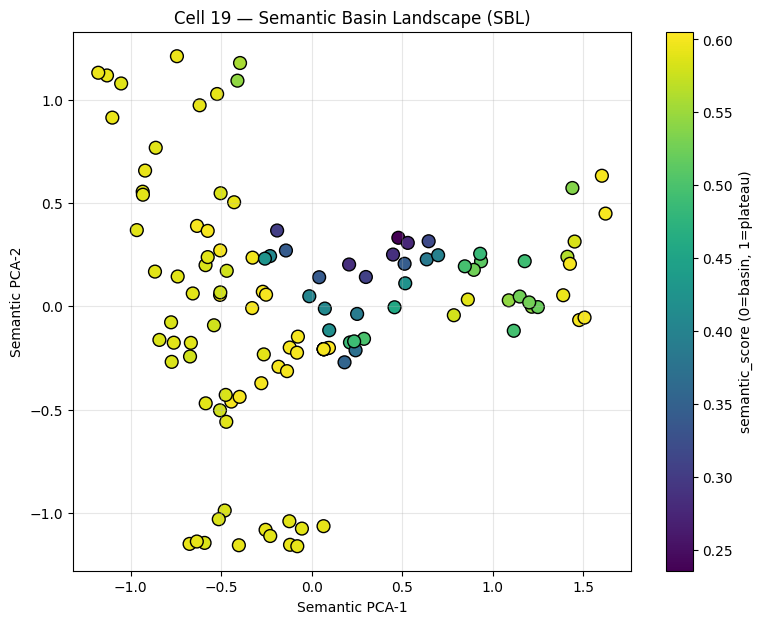

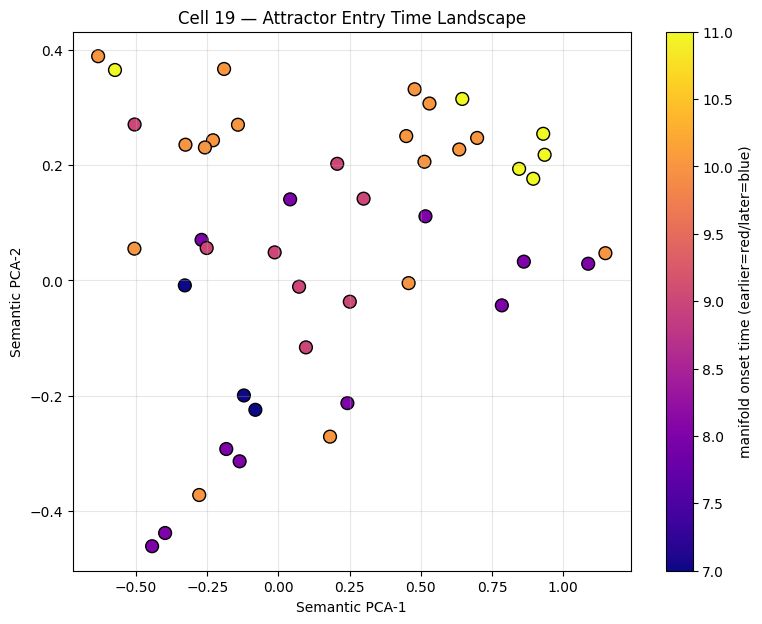

Cell 19 OK — Semantic Basin Landscape generated.


In [20]:
# ================================================================
# Cell 19 — Semantic Basin Landscape (SBL)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from sklearn.decomposition import PCA


# ----------------------------------------------------------
# Step 1: 收集语义向量（与 Cell 16 类似）
# ----------------------------------------------------------
def collect_semantic_for_landscape(N=120, T=40):
    phase_gate = make_phase_gate(T=T)

    vecs_list = []
    scores_list = []
    mani_onsets = []
    sem_onsets = []
    curv_onsets = []

    for i in range(N):
        spec = generate_random_spectrum()

        # 运行一次 pipeline
        RG, BY, RG_fb, BY_fb, BW, COLOR, Energy_ts, F_vals, stop_t = \
            run_energy_pipeline(
                spec,
                receptor_sens,
                wavelengths,
                T=T,
                gate=phase_gate,
                use_energy_noise=False
            )

        if stop_t is None:
            stop_t = len(COLOR) - 1

        # 截断所有序列（robust）
        COLOR = COLOR[:stop_t+1]
        BW = BW[:stop_t+1]
        RG = RG[:stop_t+1]
        BY = BY[:stop_t+1]
        Energy_ts = Energy_ts[:stop_t+1]

        # 构建高维语义向量
        v_end = np.array([
            COLOR[-1], BW[-1], RG[-1], BY[-1], Energy_ts[-1]
        ])

        vecs_list.append(v_end)

        # 语义成熟度分数
        score = compute_semantic_score(BW, COLOR, stop_t)
        scores_list.append(score)

        # 三种 onset
        o_sem = detect_semantic_onset(BW, COLOR)
        o_curv = detect_curvature_onset(BW, COLOR)
        # 用 attractor 做 manifold 判断
        attractor_idx = np.where((COLOR > 0.5) | (BW > 0.5))[0]
        if len(attractor_idx) < 3:
            attractor_points = np.stack([COLOR, BW, RG, BY, Energy_ts], axis=1)[-3:]
        else:
            attractor_points = np.stack([COLOR, BW, RG, BY, Energy_ts], axis=1)[attractor_idx]

        o_mani = detect_manifold_entry(
            np.stack([COLOR, BW, RG, BY, Energy_ts], axis=1),
            attractor_points
        )

        sem_onsets.append(o_sem if o_sem is not None else -1)
        curv_onsets.append(o_curv if o_curv is not None else -1)
        mani_onsets.append(o_mani if o_mani is not None else -1)

    return (
        np.array(vecs_list),
        np.array(scores_list),
        np.array(sem_onsets),
        np.array(curv_onsets),
        np.array(mani_onsets)
    )



# ----------------------------------------------------------
# Step 2: 使用 PCA 将语义向量映射至 2D 平面（X,Y）
# ----------------------------------------------------------
def project_landscape(vecs):
    pca = PCA(n_components=2)
    xy = pca.fit_transform(vecs)
    print("PCA variance ratio:", pca.explained_variance_ratio_)
    return xy[:,0], xy[:,1]



# ----------------------------------------------------------
# Step 3: 绘制语义地形图（Semantic Basin Landscape）
# ----------------------------------------------------------
def plot_semantic_landscape(x, y, scores, mani_onsets):
    plt.figure(figsize=(9,7))

    # Z 轴 = semantic_score (你会看到语义高低地形)
    sc = plt.scatter(
        x, y,
        c=scores,
        cmap='viridis',
        s=85,
        edgecolor='black'
    )

    plt.colorbar(sc, label="semantic_score (0=basin, 1=plateau)")
    plt.title("Cell 19 — Semantic Basin Landscape (SBL)")
    plt.xlabel("Semantic PCA-1")
    plt.ylabel("Semantic PCA-2")
    plt.grid(alpha=0.3)
    plt.show()

    # ------------------ 语义成形时间（manifold onset）着色版本 ------------------
    plt.figure(figsize=(9,7))
    # 我们让 “早进入吸引子 → 颜色偏暖” ，“晚进入 → 偏冷”
    onset_norm = np.array(mani_onsets, dtype=float)
    onset_norm[onset_norm<0] = np.nan  # 处理 None
    sc2 = plt.scatter(
        x, y,
        c=onset_norm,
        cmap='plasma',
        s=85,
        edgecolor='black'
    )
    plt.colorbar(sc2, label="manifold onset time (earlier=red/later=blue)")
    plt.title("Cell 19 — Attractor Entry Time Landscape")
    plt.xlabel("Semantic PCA-1")
    plt.ylabel("Semantic PCA-2")
    plt.grid(alpha=0.3)
    plt.show()



# ============================================================
# Run Cell 19
# ============================================================
vecs, scores, o_sem, o_curv, o_mani = collect_semantic_for_landscape(N=120)

x, y = project_landscape(vecs)
plot_semantic_landscape(x, y, scores, o_mani)

print("Cell 19 OK — Semantic Basin Landscape generated.")

In [ ]:
# ================================================================
# Cell 20 — Semantic Flow Field (SFF)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# ----------------------------------------------------------
# Step 1: 收集每条光谱的 trajectory vectors
# ----------------------------------------------------------
def collect_trajectory_vectors(N=60, T=40):
    phase_gate = make_phase_gate(T=T)

    all_vecs = []     # 每个点的语义向量（高维）
    all_vecs_next = []  # 下一步的语义向量
    traj_endpoints = [] # 终点语义态（用于图中叠加）

    for _ in range(N):
        spec = generate_random_spectrum()

        RG, BY, RG_fb, BY_fb, BW, COLOR, E_ts, F_vals, stop_t = \
            run_energy_pipeline(
                spec,
                receptor_sens,
                wavelengths,
                T=T,
                gate=phase_gate,
                use_energy_noise=False
            )

        if stop_t is None:
            stop_t = len(COLOR) - 1

        COLOR = COLOR[:stop_t+1]
        BW    = BW[:stop_t+1]
        RG    = RG[:stop_t+1]
        BY    = BY[:stop_t+1]
        E_ts  = E_ts[:stop_t+1]

        # 构建轨迹
        vec_seq = np.stack([COLOR, BW, RG, BY, E_ts], axis=1)

        # 收集轨迹向量 (v(t), v(t+1))
        for t in range(len(vec_seq)-1):
            all_vecs.append(vec_seq[t])
            all_vecs_next.append(vec_seq[t+1])

        # 保存轨迹终点（吸引子位置）
        traj_endpoints.append(vec_seq[-1])

    return np.array(all_vecs), np.array(all_vecs_next), np.array(traj_endpoints)


# ----------------------------------------------------------
# Step 2: PCA 投影流场
# ----------------------------------------------------------
def project_to_pca(all_vecs, all_vecs_next, traj_endpoints):
    pca = PCA(n_components=2)
    pca.fit(all_vecs)  # 用所有点拟合 PCA 流形

    XY      = pca.transform(all_vecs)
    XY_next = pca.transform(all_vecs_next)
    XY_end  = pca.transform(traj_endpoints)

    return XY, XY_next, XY_end, pca


# ----------------------------------------------------------
# Step 3: 绘制流场
# ----------------------------------------------------------
def plot_semantic_flow(XY, XY_next, XY_end, density=0.12):
    # 计算方向向量
    U = XY_next[:,0] - XY[:,0]
    V = XY_next[:,1] - XY[:,1]

    # 采样稀疏点，避免流场太密
    mask = np.random.rand(len(U)) < density

    Xs = XY[mask,0]
    Ys = XY[mask,1]
    Us = U[mask]
    Vs = V[mask]

    plt.figure(figsize=(9,8))

    # 流场箭头
    plt.quiver(
        Xs, Ys,
        Us, Vs,
        angles='xy',
        scale_units='xy',
        scale=1.5,
        color="steelblue",
        alpha=0.55
    )

    # 叠加终点（semantic attractor locations）
    plt.scatter(
        XY_end[:,0],
        XY_end[:,1],
        c='gold',
        s=100,
        edgecolor='black',
        label="Attractor endpoints"
    )

    plt.title("Cell 20 — Semantic Flow Field (SFF)")
    plt.xlabel("Semantic PCA-1")
    plt.ylabel("Semantic PCA-2")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


# ----------------------------------------------------------
# 执行 Cell 20
# ----------------------------------------------------------
all_vecs, all_vecs_next, traj_endpoints = collect_trajectory_vectors(N=60, T=40)
XY, XY_next, XY_end, pca_model = project_to_pca(all_vecs, all_vecs_next, traj_endpoints)
plot_semantic_flow(XY, XY_next, XY_end)

print("Cell 20 OK — Semantic Flow Field generated.")

NameError: name 'make_phase_gate' is not defined

[Soft-Gate] Terminated at t = 9  (F = 0.1406)
[Soft-Gate] Terminated at t = 6  (F = 0.1248)
[Soft-Gate] Terminated at t = 5  (F = 0.1400)
[Soft-Gate] Terminated at t = 5  (F = 0.1212)
[Soft-Gate] Terminated at t = 7  (F = 0.1426)
[Soft-Gate] Terminated at t = 5  (F = 0.1204)
[Soft-Gate] Terminated at t = 8  (F = 0.1461)
[Soft-Gate] Terminated at t = 8  (F = 0.1487)
[Soft-Gate] Terminated at t = 5  (F = 0.1255)
[Soft-Gate] Terminated at t = 10  (F = 0.1468)
[Soft-Gate] Terminated at t = 4  (F = 0.1246)
[Soft-Gate] Terminated at t = 6  (F = 0.1269)
[Soft-Gate] Terminated at t = 5  (F = 0.1417)
[Soft-Gate] Terminated at t = 6  (F = 0.1309)
[Soft-Gate] Terminated at t = 5  (F = 0.1185)
[Soft-Gate] Terminated at t = 6  (F = 0.1401)
[Soft-Gate] Terminated at t = 4  (F = 0.1246)
[Soft-Gate] Terminated at t = 5  (F = 0.1179)
[Soft-Gate] Terminated at t = 8  (F = 0.1313)
[Soft-Gate] Terminated at t = 5  (F = 0.1236)
[Soft-Gate] Terminated at t = 7  (F = 0.1201)
[Soft-Gate] Terminated at t = 7  

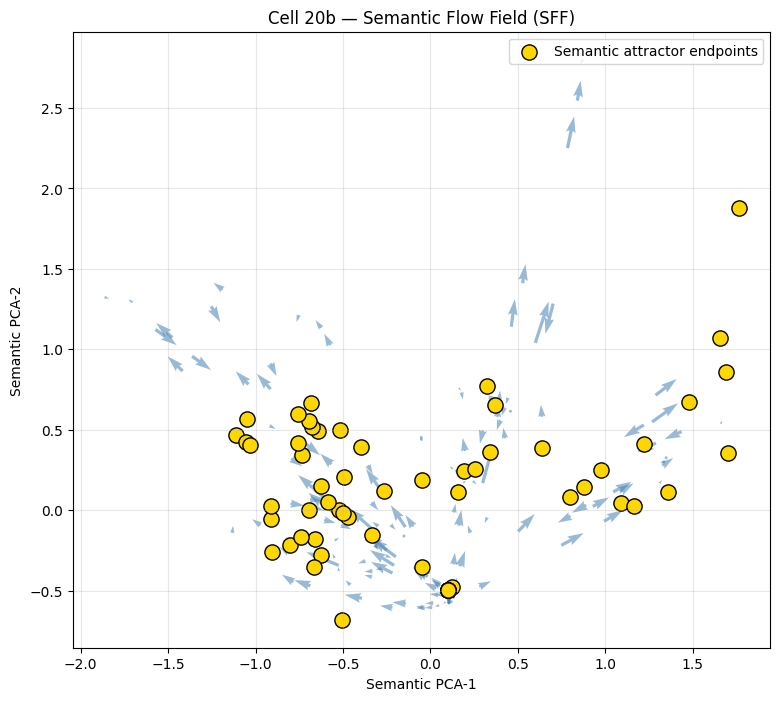

Cell 20b OK — Semantic Flow Field generated.


In [21]:
# ================================================================
# Cell 20b — Semantic Flow Field (Standalone + Robust)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


# ----------------------------------------------------------
# 内置：make_phase_gate（来自 Cell 9）
# ----------------------------------------------------------
def make_phase_gate(T=40, freq=1.0, phase=0.0):
    t = np.arange(T)
    raw = np.sin(2 * np.pi * (freq * t / T) + phase) ** 2
    raw_min, raw_max = raw.min(), raw.max()
    if raw_max - raw_min < 1e-12:
        norm = np.ones(T)
    else:
        norm = (raw - raw_min) / (raw_max - raw_min)
    return 0.1 + 0.9 * norm


# ----------------------------------------------------------
# Step 1: 收集语义轨迹
# ----------------------------------------------------------
def collect_trajectory_vectors(N=60, T=40):
    phase_gate = make_phase_gate(T=T)

    all_vecs = []
    all_vecs_next = []
    traj_endpoints = []

    for _ in range(N):
        spec = generate_random_spectrum()

        RG, BY, RG_fb, BY_fb, BW, COLOR, E_ts, F_vals, stop_t = \
            run_energy_pipeline(
                spec,
                receptor_sens,
                wavelengths,
                T=T,
                gate=phase_gate,
                use_energy_noise=False
            )

        if stop_t is None:
            stop_t = len(COLOR) - 1

        # 截断全部序列（与 early-stop 对齐）
        COLOR = COLOR[:stop_t+1]
        BW    = BW[:stop_t+1]
        RG    = RG[:stop_t+1]
        BY    = BY[:stop_t+1]
        E_ts  = E_ts[:stop_t+1]

        # 高维状态序列
        vec_seq = np.stack([COLOR, BW, RG, BY, E_ts], axis=1)

        for t in range(len(vec_seq)-1):
            all_vecs.append(vec_seq[t])
            all_vecs_next.append(vec_seq[t+1])

        traj_endpoints.append(vec_seq[-1])

    return np.array(all_vecs), np.array(all_vecs_next), np.array(traj_endpoints)


# ----------------------------------------------------------
# Step 2: PCA 映射
# ----------------------------------------------------------
def project_to_pca(all_vecs, all_vecs_next, traj_endpoints):
    pca = PCA(n_components=2)
    pca.fit(all_vecs)

    XY      = pca.transform(all_vecs)
    XY_next = pca.transform(all_vecs_next)
    XY_end  = pca.transform(traj_endpoints)

    print("PCA variance ratio:", pca.explained_variance_ratio_)
    return XY, XY_next, XY_end


# ----------------------------------------------------------
# Step 3: 绘制语义流场
# ----------------------------------------------------------
def plot_semantic_flow(XY, XY_next, XY_end, density=0.12):
    U = XY_next[:,0] - XY[:,0]
    V = XY_next[:,1] - XY[:,1]

    # 稀疏采样，避免过密
    mask = np.random.rand(len(U)) < density

    Xs = XY[mask,0]
    Ys = XY[mask,1]
    Us = U[mask]
    Vs = V[mask]

    plt.figure(figsize=(9,8))

    # 流场箭头
    plt.quiver(
        Xs, Ys, Us, Vs,
        angles='xy', scale_units='xy', scale=1.5,
        color="steelblue", alpha=0.55
    )

    # 终点吸引子位置
    plt.scatter(
        XY_end[:,0], XY_end[:,1],
        c='gold', s=120,
        edgecolor='black',
        label="Semantic attractor endpoints"
    )

    plt.title("Cell 20b — Semantic Flow Field (SFF)")
    plt.xlabel("Semantic PCA-1")
    plt.ylabel("Semantic PCA-2")
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()


# ----------------------------------------------------------
# Execute Cell 20b
# ----------------------------------------------------------
all_vecs, all_vecs_next, traj_endpoints = collect_trajectory_vectors(N=60, T=40)
XY, XY_next, XY_end = project_to_pca(all_vecs, all_vecs_next, traj_endpoints)

plot_semantic_flow(XY, XY_next, XY_end)

print("Cell 20b OK — Semantic Flow Field generated.")

[Soft-Gate] Terminated at t = 4  (F = 0.1096)
[Soft-Gate] Terminated at t = 8  (F = 0.1460)
[Soft-Gate] Terminated at t = 6  (F = 0.1477)
[Soft-Gate] Terminated at t = 5  (F = 0.1240)
[Soft-Gate] Terminated at t = 5  (F = 0.1361)
[Soft-Gate] Terminated at t = 4  (F = 0.1437)
[Soft-Gate] Terminated at t = 5  (F = 0.1255)
[Soft-Gate] Terminated at t = 5  (F = 0.0964)
[Soft-Gate] Terminated at t = 5  (F = 0.1258)
[Soft-Gate] Terminated at t = 4  (F = 0.1359)
[Soft-Gate] Terminated at t = 5  (F = 0.1468)
[Soft-Gate] Terminated at t = 5  (F = 0.1097)
[Soft-Gate] Terminated at t = 8  (F = 0.1423)
[Soft-Gate] Terminated at t = 4  (F = 0.1113)
[Soft-Gate] Terminated at t = 8  (F = 0.1414)
[Soft-Gate] Terminated at t = 5  (F = 0.1498)
[Soft-Gate] Terminated at t = 8  (F = 0.1427)
[Soft-Gate] Terminated at t = 4  (F = 0.1357)
[Soft-Gate] Terminated at t = 7  (F = 0.1439)
[Soft-Gate] Terminated at t = 3  (F = 0.1289)
[Soft-Gate] Terminated at t = 4  (F = 0.1075)
[Soft-Gate] Terminated at t = 8  (

c:\Users\cheny\anaconda3\envs\vtdc\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


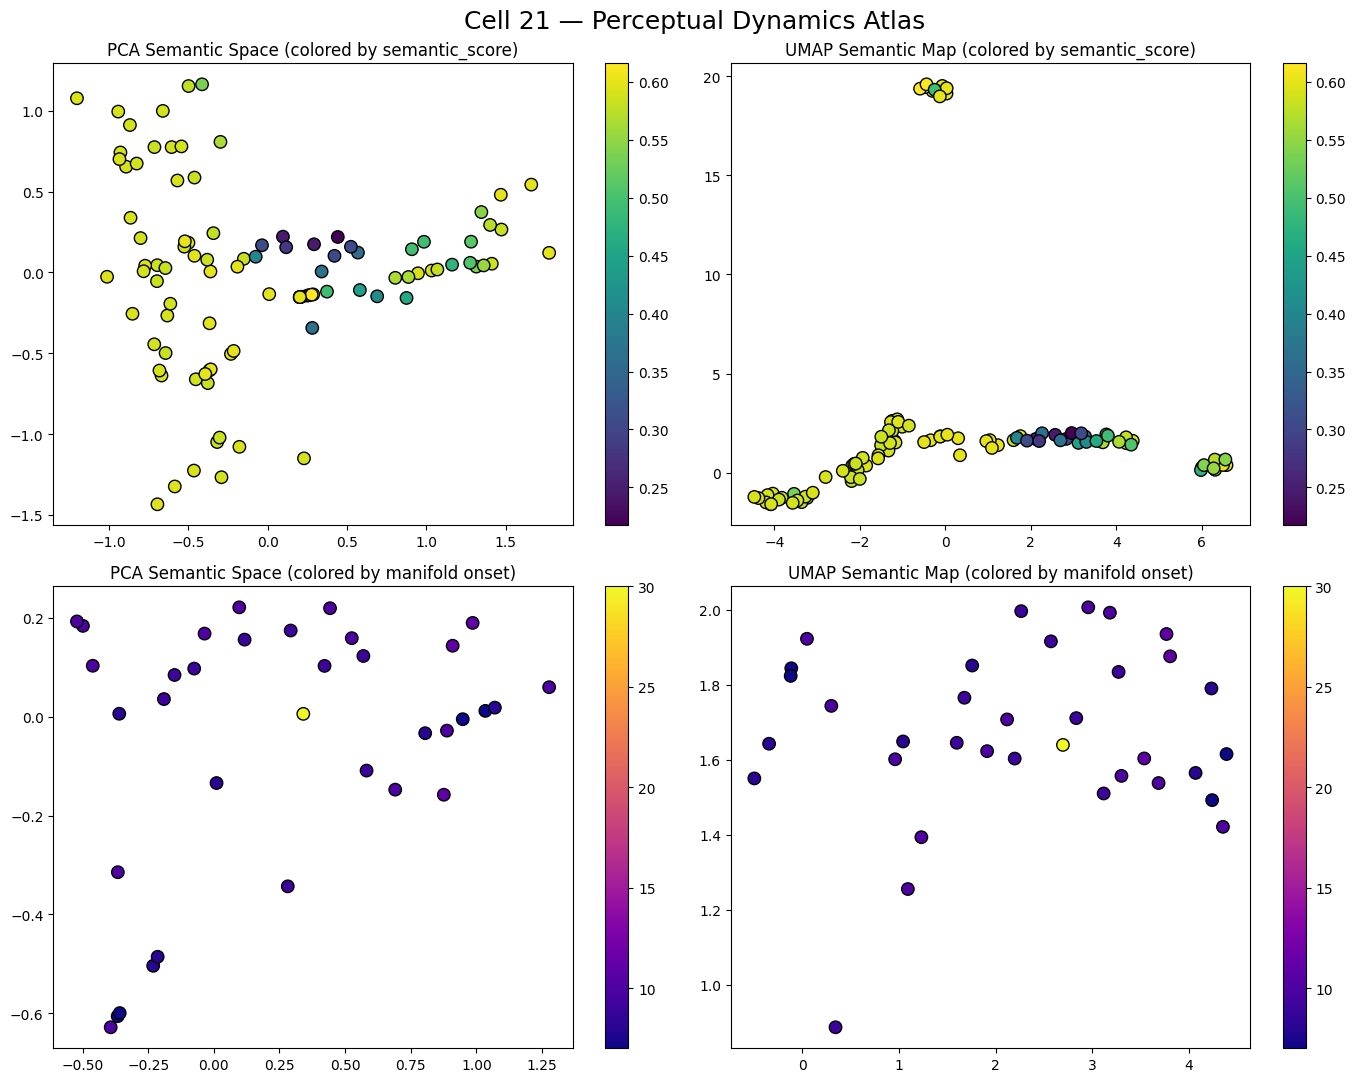

Cell 21 OK — Perceptual Dynamics Atlas generated.


In [22]:
# ================================================================
# Cell 21 — Perceptual Dynamics Atlas (PDA)
# ================================================================
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import umap


# ----------------------------------------------------------
# Step 1 — 收集终态语义向量（用于 PCA / UMAP）
# ----------------------------------------------------------
def collect_semantic_endpoints(N=100, T=40):
    phase_gate = make_phase_gate(T=T)
    vecs_list = []
    scores_list = []
    mani_onsets = []

    for _ in range(N):
        spec = generate_random_spectrum()
        RG, BY, RG_fb, BY_fb, BW, COLOR, E_ts, F_vals, stop_t = \
            run_energy_pipeline(spec, receptor_sens, wavelengths, T=T, gate=phase_gate)

        if stop_t is None:
            stop_t = len(COLOR) - 1

        COLOR = COLOR[:stop_t+1]
        BW    = BW[:stop_t+1]
        RG    = RG[:stop_t+1]
        BY    = BY[:stop_t+1]
        E_ts  = E_ts[:stop_t+1]

        v = np.array([COLOR[-1], BW[-1], RG[-1], BY[-1], E_ts[-1]])
        vecs_list.append(v)

        score = compute_semantic_score(BW, COLOR, stop_t)
        scores_list.append(score)

        # detect manifold onset
        attractor_idx = np.where((COLOR>0.5) | (BW>0.5))[0]
        vec_seq = np.stack([COLOR, BW, RG, BY, E_ts], axis=1)

        if len(attractor_idx)<3:
            attractor_points = vec_seq[-3:]
        else:
            attractor_points = vec_seq[attractor_idx]

        o_mani = detect_manifold_entry(vec_seq, attractor_points)
        mani_onsets.append(o_mani if o_mani is not None else -1)

    return np.array(vecs_list), np.array(scores_list), np.array(mani_onsets)


# ----------------------------------------------------------
# Step 2 — PCA / UMAP projection
# ----------------------------------------------------------
def project_semantic_space(vecs):
    pca = PCA(n_components=2)
    XY_pca = pca.fit_transform(vecs)

    reducer = umap.UMAP(
        n_neighbors=20, min_dist=0.1, metric='euclidean', random_state=42
    )
    XY_umap = reducer.fit_transform(vecs)

    return XY_pca, XY_umap


# ----------------------------------------------------------
# Step 3 — 绘制 Atlas
# ----------------------------------------------------------
def plot_perceptual_atlas(XY_pca, XY_umap, scores, mani_onsets):
    fig, axes = plt.subplots(2, 2, figsize=(14,11))
    
    # --- (1) PCA + semantic_score ---
    ax = axes[0,0]
    sc = ax.scatter(XY_pca[:,0], XY_pca[:,1], c=scores, cmap="viridis", s=80, edgecolor='black')
    ax.set_title("PCA Semantic Space (colored by semantic_score)")
    fig.colorbar(sc, ax=ax)

    # --- (2) UMAP + semantic_score ---
    ax = axes[0,1]
    sc = ax.scatter(XY_umap[:,0], XY_umap[:,1], c=scores, cmap="viridis", s=80, edgecolor='black')
    ax.set_title("UMAP Semantic Map (colored by semantic_score)")
    fig.colorbar(sc, ax=ax)

    # --- (3) PCA + manifold onset ---
    ax = axes[1,0]
    onset = mani_onsets.copy().astype(float)
    onset[onset<0] = np.nan
    sc = ax.scatter(XY_pca[:,0], XY_pca[:,1], c=onset, cmap="plasma", s=80, edgecolor='black')
    ax.set_title("PCA Semantic Space (colored by manifold onset)")
    fig.colorbar(sc, ax=ax)

    # --- (4) UMAP + manifold onset ---
    ax = axes[1,1]
    sc = ax.scatter(XY_umap[:,0], XY_umap[:,1], c=onset, cmap="plasma", s=80, edgecolor='black')
    ax.set_title("UMAP Semantic Map (colored by manifold onset)")
    fig.colorbar(sc, ax=ax)

    plt.suptitle("Cell 21 — Perceptual Dynamics Atlas", fontsize=18)
    plt.tight_layout()
    plt.show()


# ============================================================
# Execute Cell 21
# ============================================================
vecs, scores, mani_onsets = collect_semantic_endpoints(N=100)
XY_pca, XY_umap           = project_semantic_space(vecs)

plot_perceptual_atlas(XY_pca, XY_umap, scores, mani_onsets)

print("Cell 21 OK — Perceptual Dynamics Atlas generated.")